In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
pa_gs = pd.read_csv('data/pa_data.csv')
pa_gs = pa_gs[pa_gs['year'] >= 1960]

def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        return X_cleaned, y_cleaned

def remove_nulls_ext(data_subset, X, y, Z):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        Z_cleaned = data_subset_cleaned[Z]
        return X_cleaned, y_cleaned, Z_cleaned

y = ['growing_season_length']
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'latitude', 'longitude', 'oni_annual',
    'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'pwat_station', 'dewpoint_2m_pennsylvania', 'soil_moisture_station','cloud_cover_station', 'evaporation_station'] 
Z = ['year', 'station_name']

### Basic PA State Residuals Analysis

In [30]:
X_all, y_all, Z_all = remove_nulls_ext(pa_gs, X, y, Z)
X_all= sm.add_constant(X_all)
             
mod_all = sm.OLS(y_all, X_all)
res_all = mod_all.fit()
print(res_all.summary())

                              OLS Regression Results                             
Dep. Variable:     growing_season_length   R-squared:                       0.669
Model:                               OLS   Adj. R-squared:                  0.668
Method:                    Least Squares   F-statistic:                     788.0
Date:                   Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                           08:24:14   Log-Likelihood:                -26900.
No. Observations:                   6254   AIC:                         5.383e+04
Df Residuals:                       6237   BIC:                         5.395e+04
Df Model:                             16                                         
Covariance Type:               nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

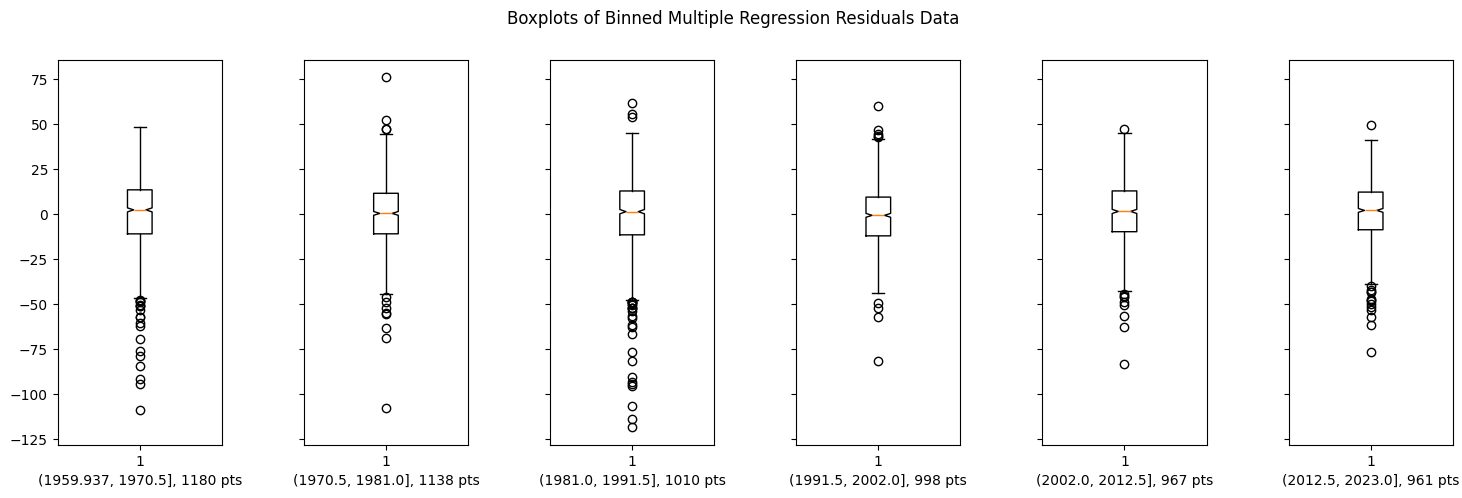

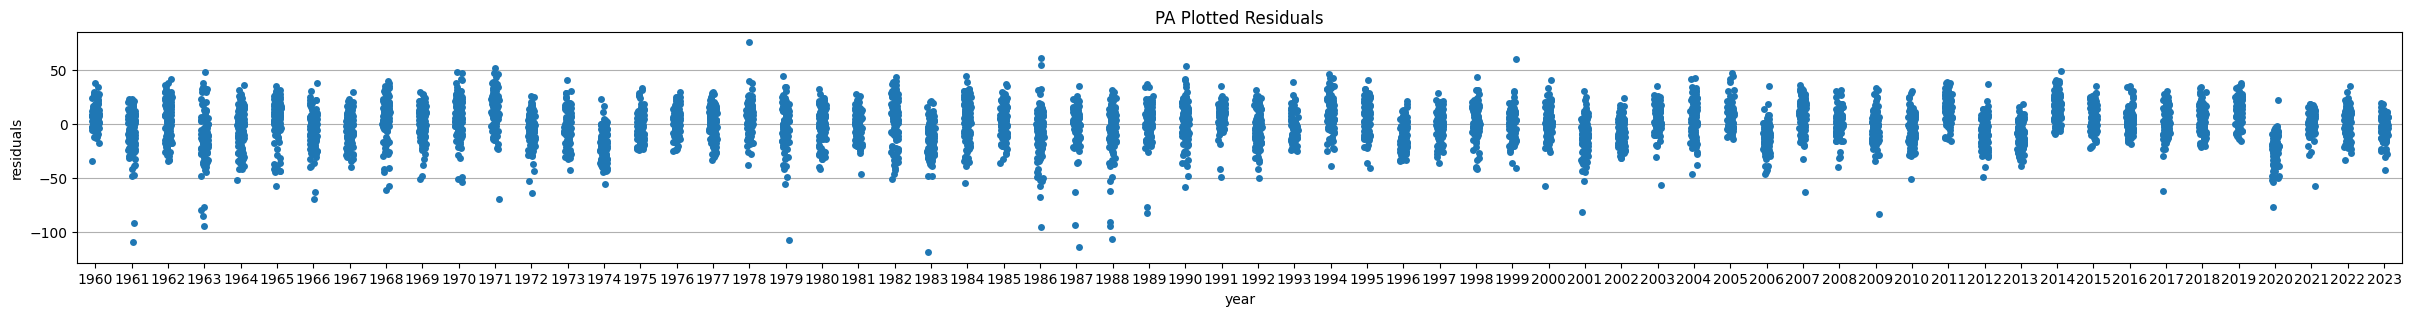

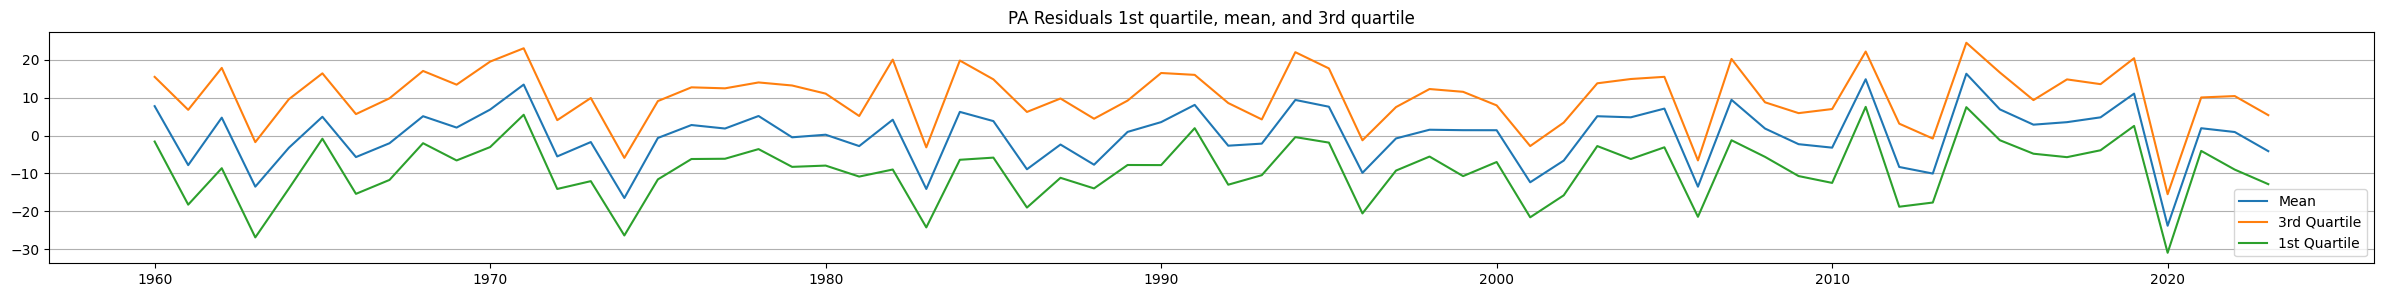

In [31]:
residuals_all = res_all.resid
res_df_all = residuals_all.to_frame()
res_df_all = pd.concat([res_df_all, Z_all], axis=1)
res_df_all.columns = ['residuals', 'year', 'station_name']

res_df_all['bins'] = pd.cut(x= res_df_all['year'], bins = 6)
res_df_all = res_df_all.sort_values(by='bins')


fig, axs = plt.subplots(1,6, sharey=True, figsize = (18, 5))
fig.suptitle('Boxplots of Binned Multiple Regression Residuals Data')
fig.subplots_adjust(wspace = 0.5)
n = 0
for value in res_df_all['bins'].unique():
    res_df_bin_all = res_df_all[res_df_all['bins'] == value]
    axs[n].boxplot(res_df_bin_all['residuals'], notch = True)
    axs[n].set_xlabel(f'{value}, {len(res_df_bin_all)} pts')
    n = n + 1
plt.show()

res_df_all_mean = res_df_all.groupby('year')['residuals'].mean()
res_df_all_mean = res_df_all_mean.to_frame()
res_df_all_mean = res_df_all_mean.reset_index()
res_df_all_mean.columns = ['year', 'residual_mean']

res_df_all_3q = res_df_all.groupby('year')['residuals'].quantile(0.75)
res_df_all_3q = res_df_all_3q.to_frame()
res_df_all_3q = res_df_all_3q.reset_index()
res_df_all_3q.columns = ['year', 'residual_3q']

res_df_all_1q = res_df_all.groupby('year')['residuals'].quantile(0.25)
res_df_all_1q = res_df_all_1q.to_frame()
res_df_all_1q = res_df_all_1q.reset_index()
res_df_all_1q.columns = ['year', 'residual_1q']

fig= plt.figure(figsize = (30,3))
fig = sns.stripplot(data = res_df_all, x = 'year', y = 'residuals')       
plt.grid(axis='y')
plt.title('PA Plotted Residuals')
plt.show

fig= plt.figure(figsize = (30,3))
fig = plt.plot(res_df_all_mean['year'], res_df_all_mean['residual_mean'], label = 'Mean')
fig = plt.plot(res_df_all_3q['year'], res_df_all_3q['residual_3q'], label = '3rd Quartile')
fig = plt.plot(res_df_all_1q['year'], res_df_all_1q['residual_1q'], label = '1st Quartile')
plt.grid(axis='y')
plt.title('PA Residuals 1st quartile, mean, and 3rd quartile')
plt.legend()
plt.show()

Am I going crazy, or is there a periodic cycle happening in the IQR from ~1980 or ~1985 to the present?

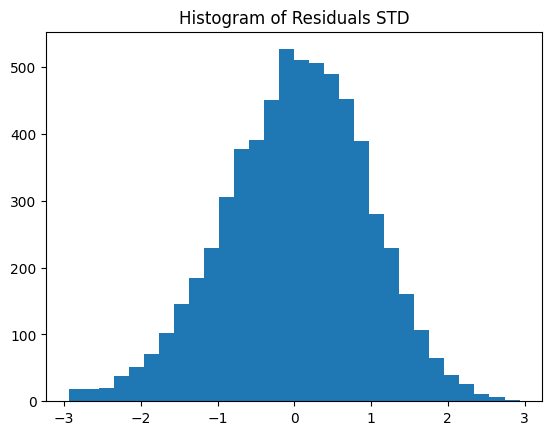

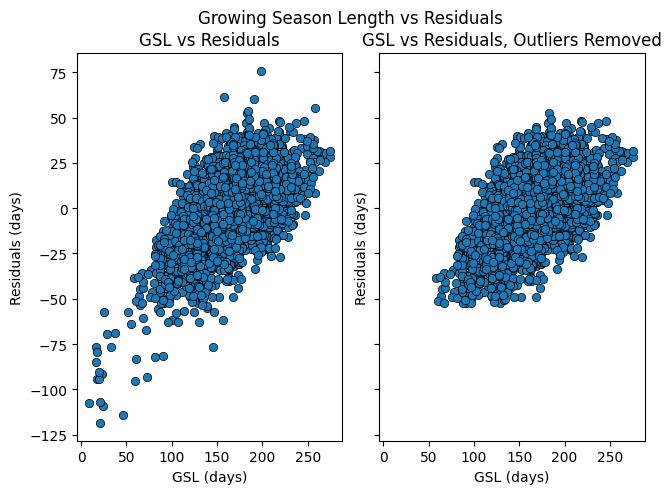

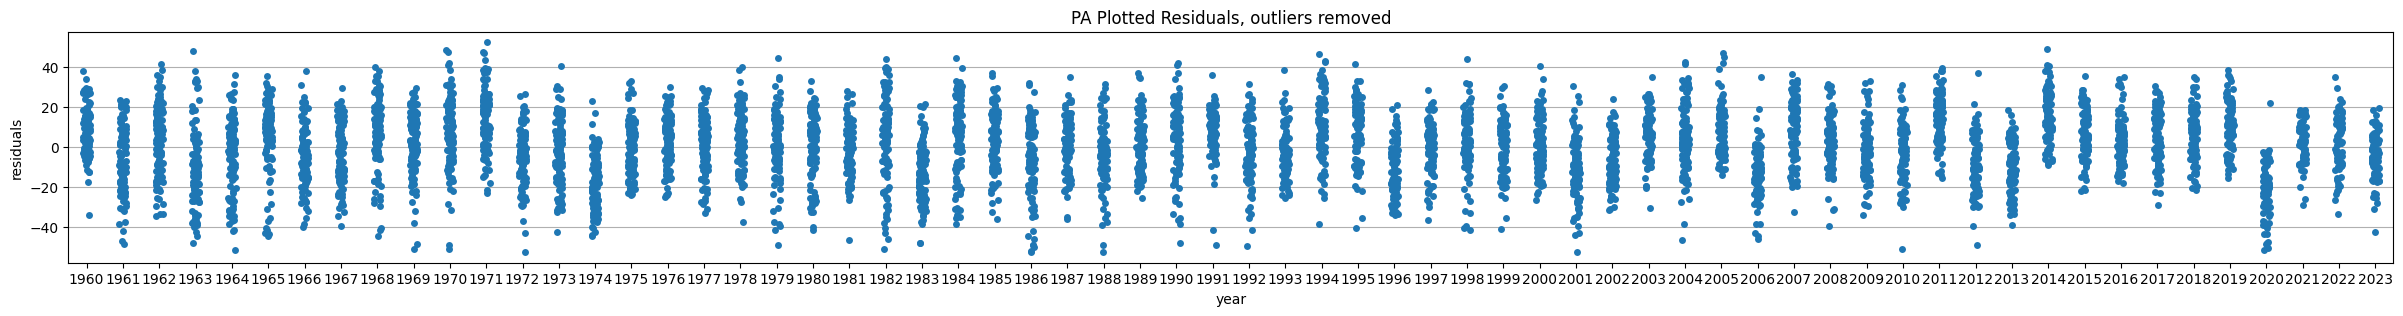

In [32]:
resid_std_val = res_df_all['residuals'].std()
resid_std = res_df_all['residuals'] / resid_std_val
res_df_std = pd.concat([res_df_all,resid_std, y_all], axis = 1)
res_df_std.columns = ['residuals', 'year', 'station_name', 'bins', 'residuals_STD', 'growing_season_length']

res_df_std = res_df_std[res_df_std['residuals_STD'].between(-3, 3)]

fig = plt.hist(res_df_std['residuals_STD'], bins = 30)
plt.title('Histogram of Residuals STD')
plt.show()

res_df_all_gs = pd.concat([res_df_all, y_all], axis = 1)

fig, axs = plt.subplots(1,2, sharey=True, sharex=True)
fig.suptitle('Growing Season Length vs Residuals')
fig.tight_layout()
axs[0].scatter(data = res_df_all_gs, x = 'growing_season_length', y = 'residuals', edgecolors = 'black', linewidths = 0.5)
axs[0].set_title('GSL vs Residuals')
axs[0].set_xlabel('GSL (days)')
axs[0].set_ylabel('Residuals (days)')
axs[1].scatter(data = res_df_std, x = 'growing_season_length', y = 'residuals', edgecolors = 'black', linewidths = 0.5)
axs[1].set_title('GSL vs Residuals, Outliers Removed')
axs[1].set_xlabel('GSL (days)')
axs[1].set_ylabel('Residuals (days)')
plt.show()

fig= plt.figure(figsize = (30,3))
fig = sns.stripplot(data = res_df_std, x = 'year', y = 'residuals')       
plt.grid(axis='y')
plt.title('PA Plotted Residuals, outliers removed')
plt.show()

### Heteroscedasticity by Station

In [33]:
def station_residuals_plotting(station_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(pa_gs[pa_gs['station_name'] == station_name], X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df = residuals_s.to_frame()
    res_df = pd.concat([res_df, Z_s], axis=1)
    res_df.columns = ['residuals', 'year', 'station_name']
    
    res_df['bins'] = pd.cut(x= res_df['year'], bins = bin_no)
    res_df = res_df.sort_values(by='bins')
    
    
    fig, axs = plt.subplots(1,bin_no, sharey=True, figsize = (bin_no * 2, 5))
    fig.suptitle(f'Boxplots of Binned Multiple Regression Residuals Data for {station_name}, PA')
    fig.subplots_adjust(wspace = bin_no * 3/5)
    n = 0
    for value in res_df['bins'].unique():
        res_df_bin = res_df[res_df['bins'] == value]
        axs[n].boxplot(res_df_bin['residuals'], notch= True)
        axs[n].set_xlabel(f'{value}, {len(res_df_bin)} pts')
        n = n + 1
    plt.show()

    fig = plt.figure(figsize = (30,3))
    fig = sns.stripplot(data = res_df, x = 'year', y = 'residuals')
    plt.grid(axis='y')
    plt.title(f'Plotted Residuals for {station_name}')
    plt.show()

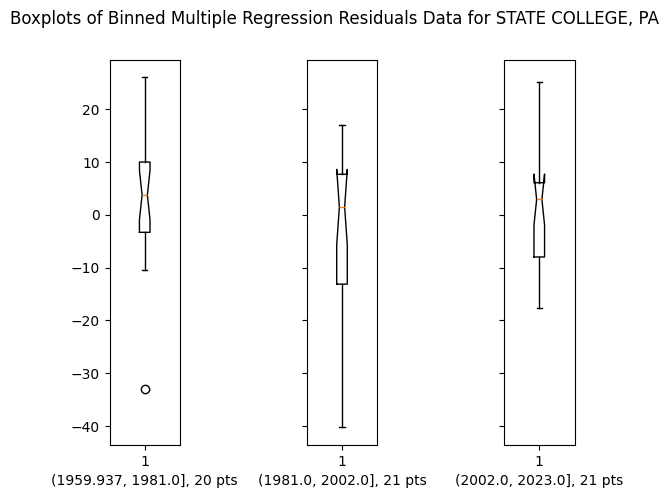

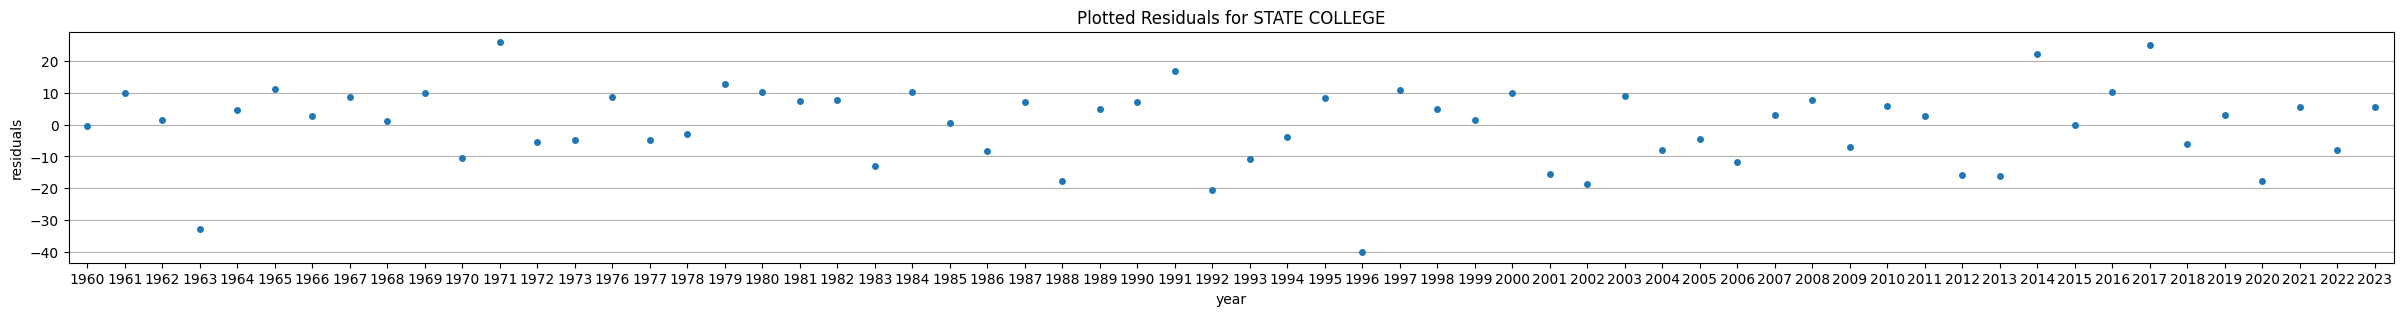

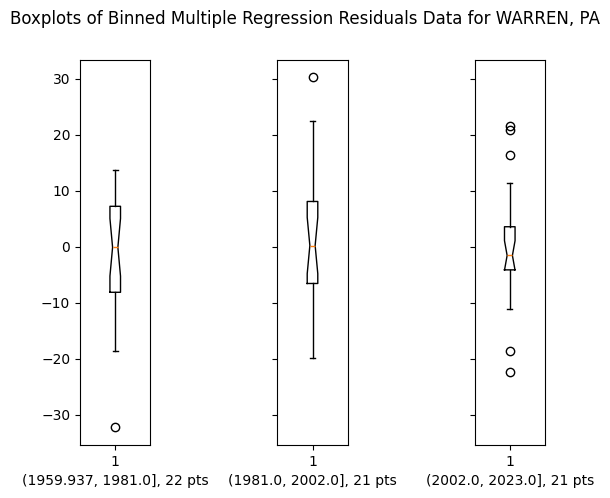

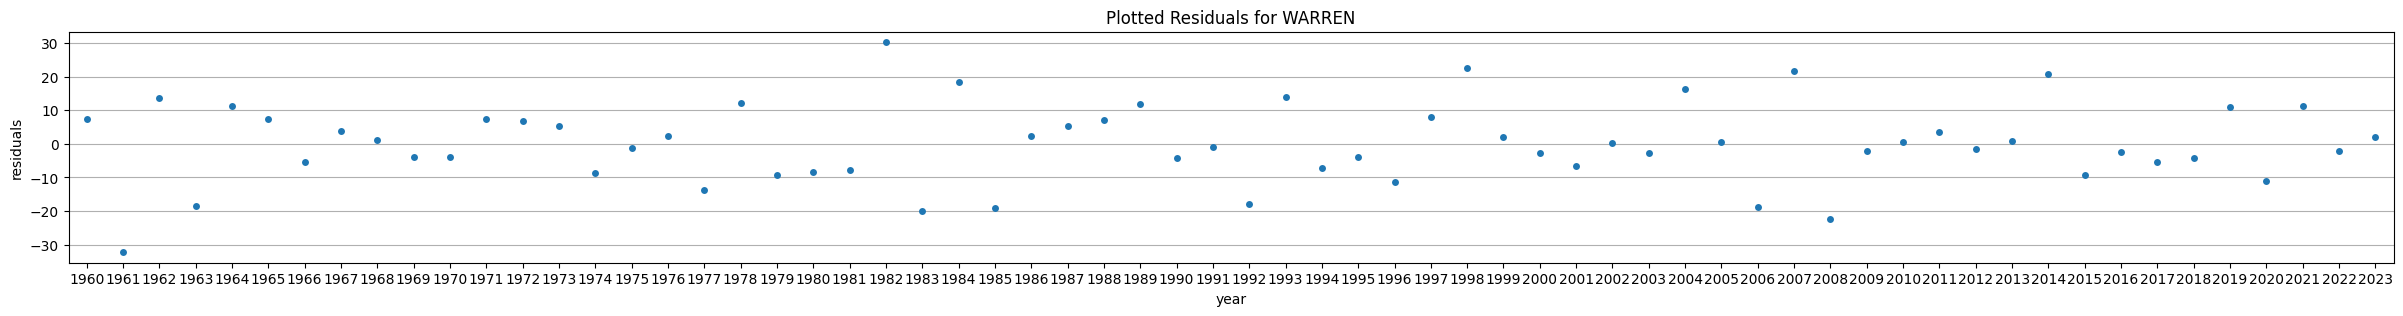

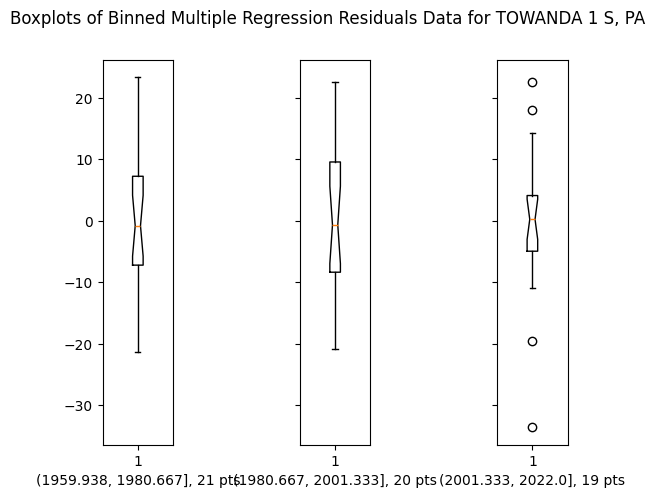

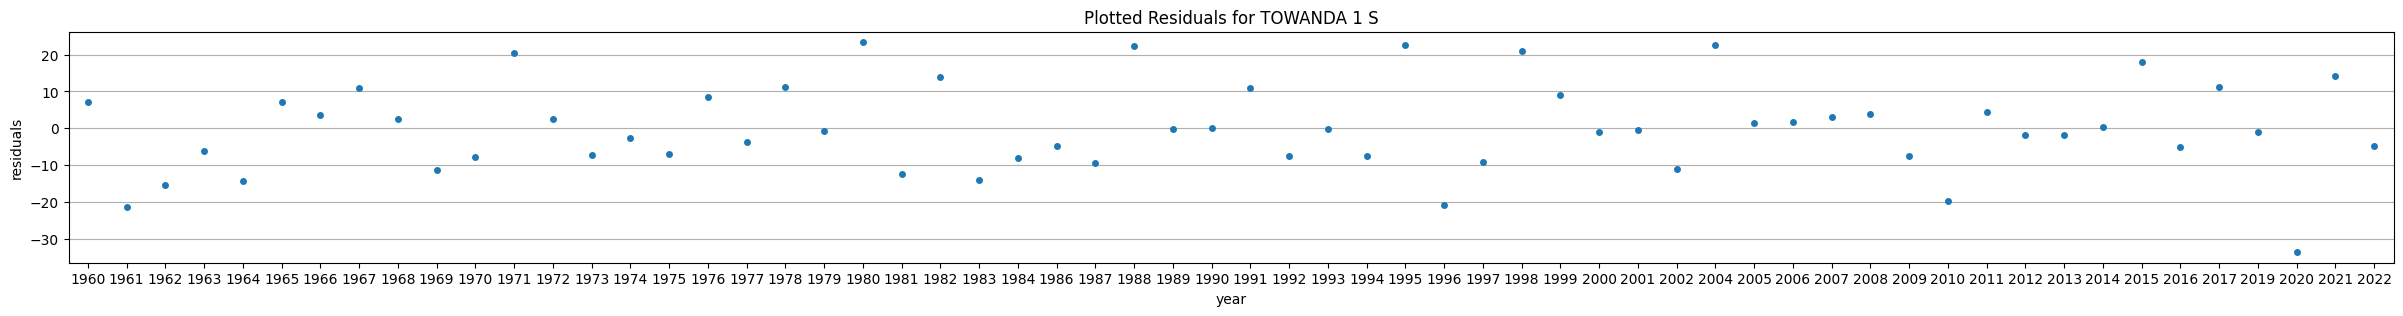

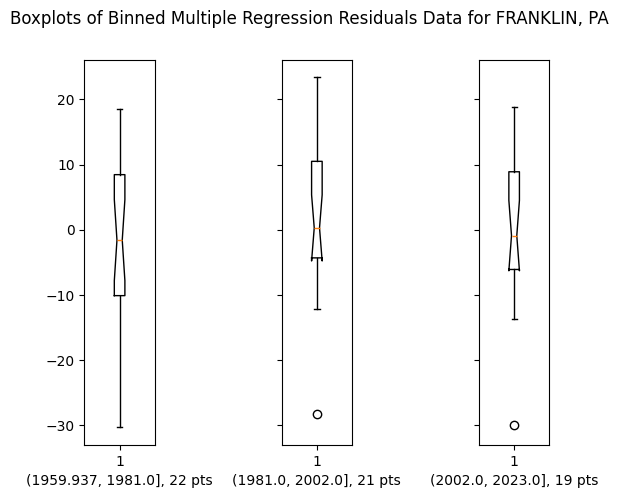

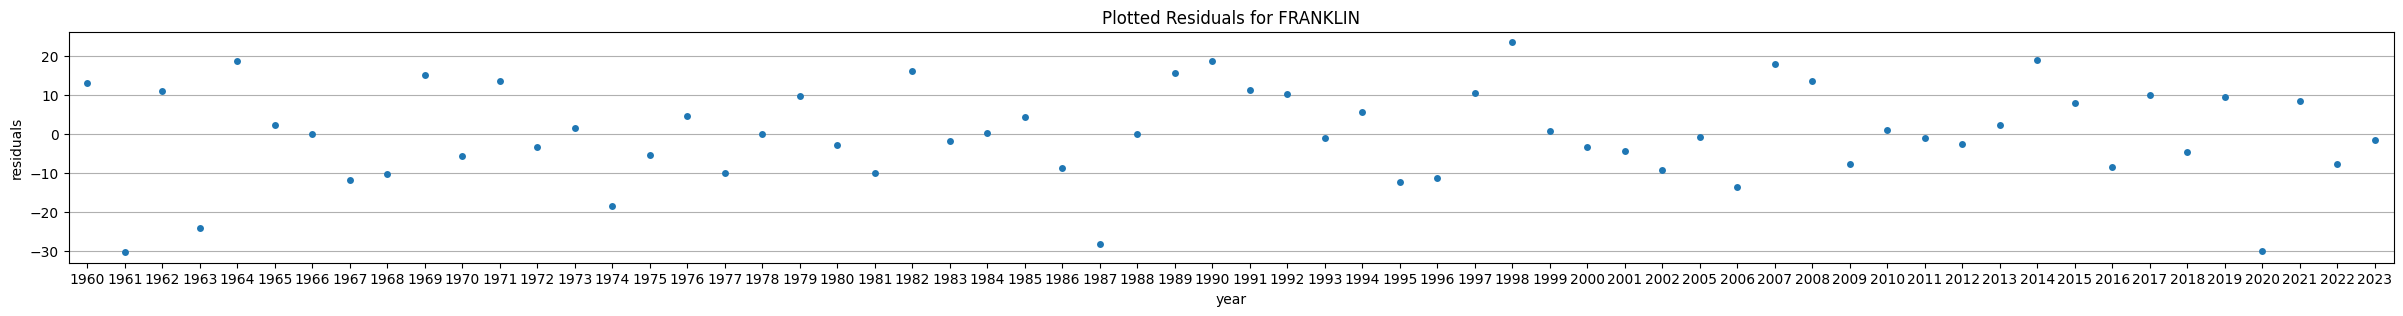

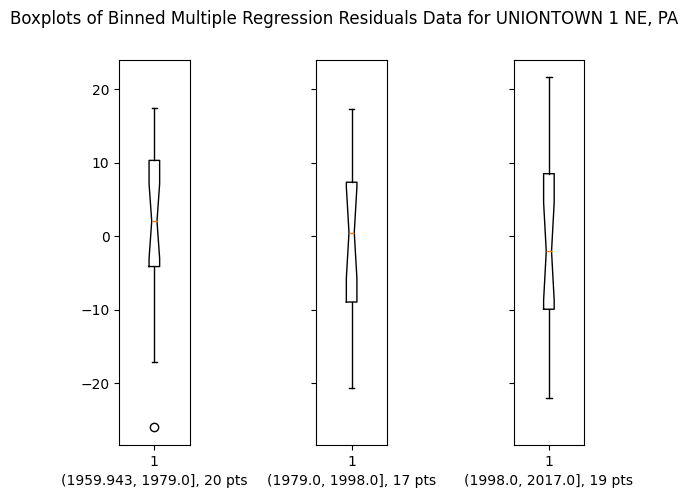

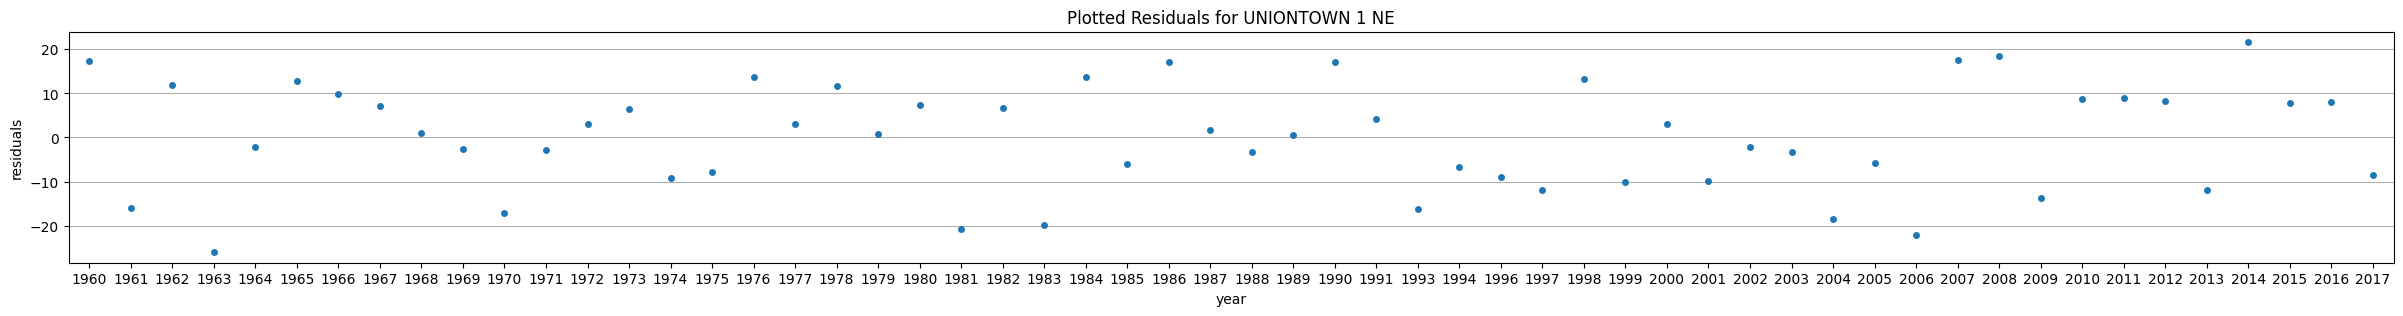

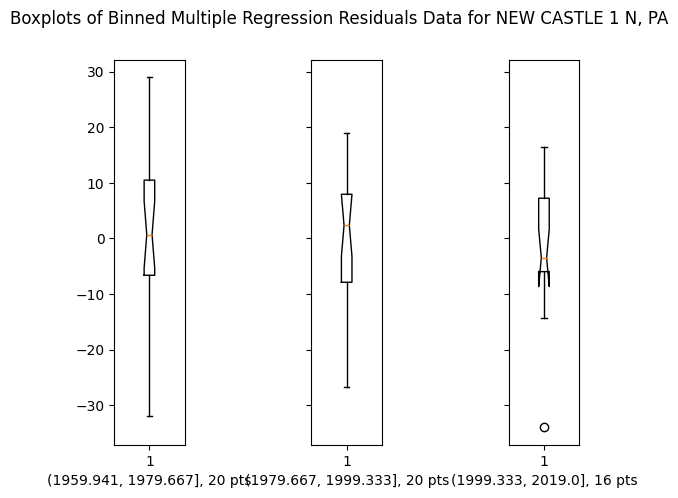

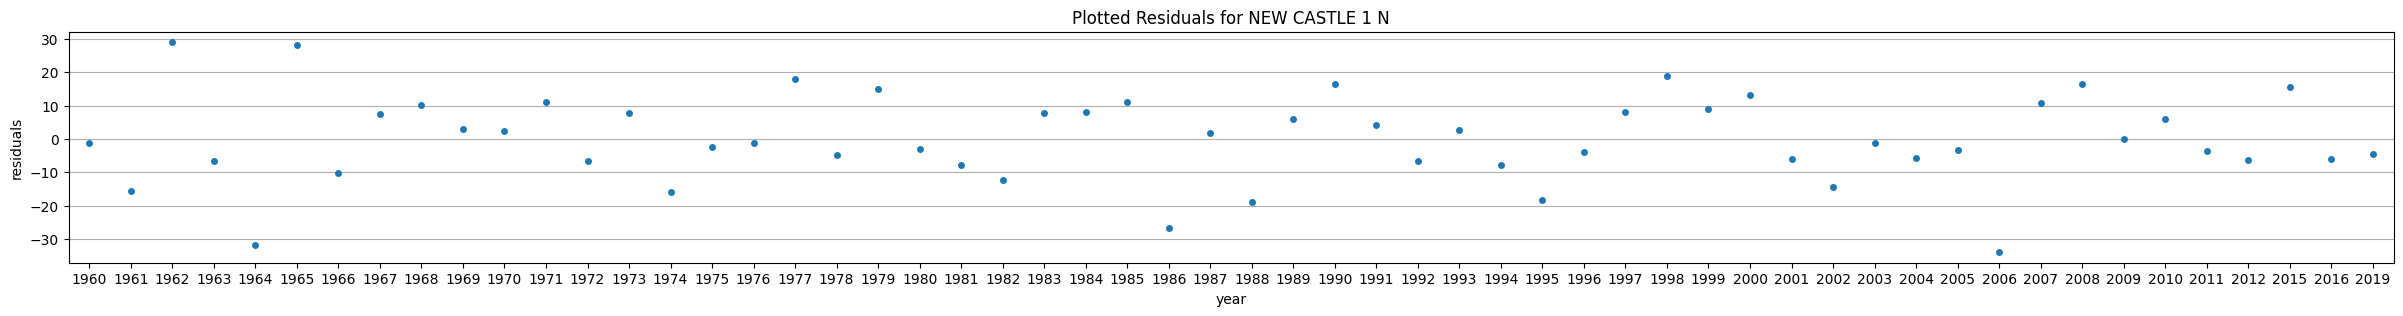

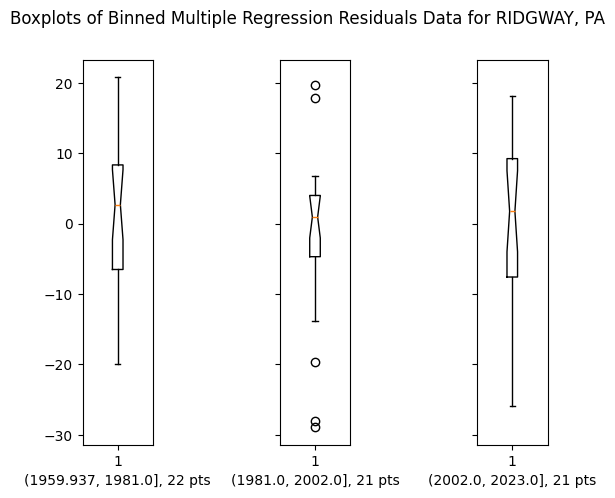

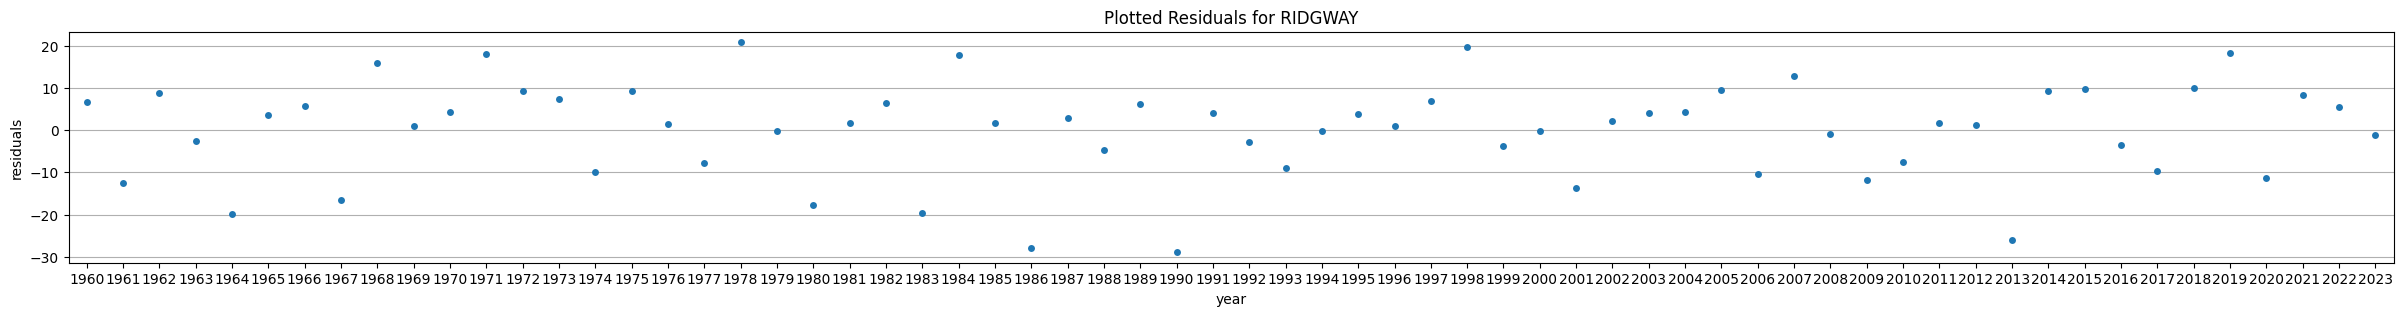

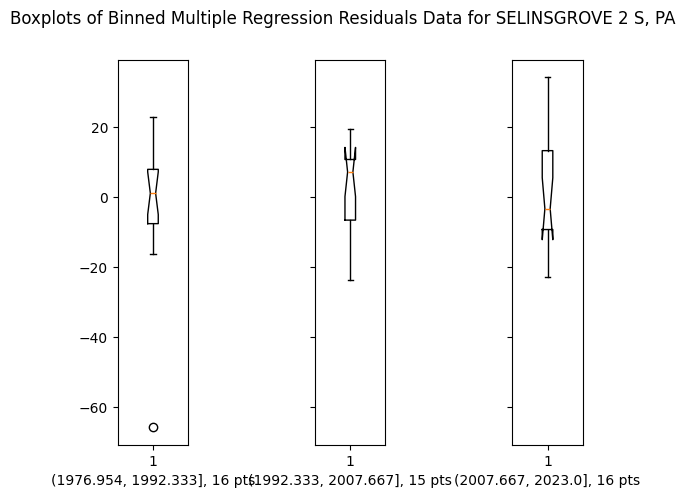

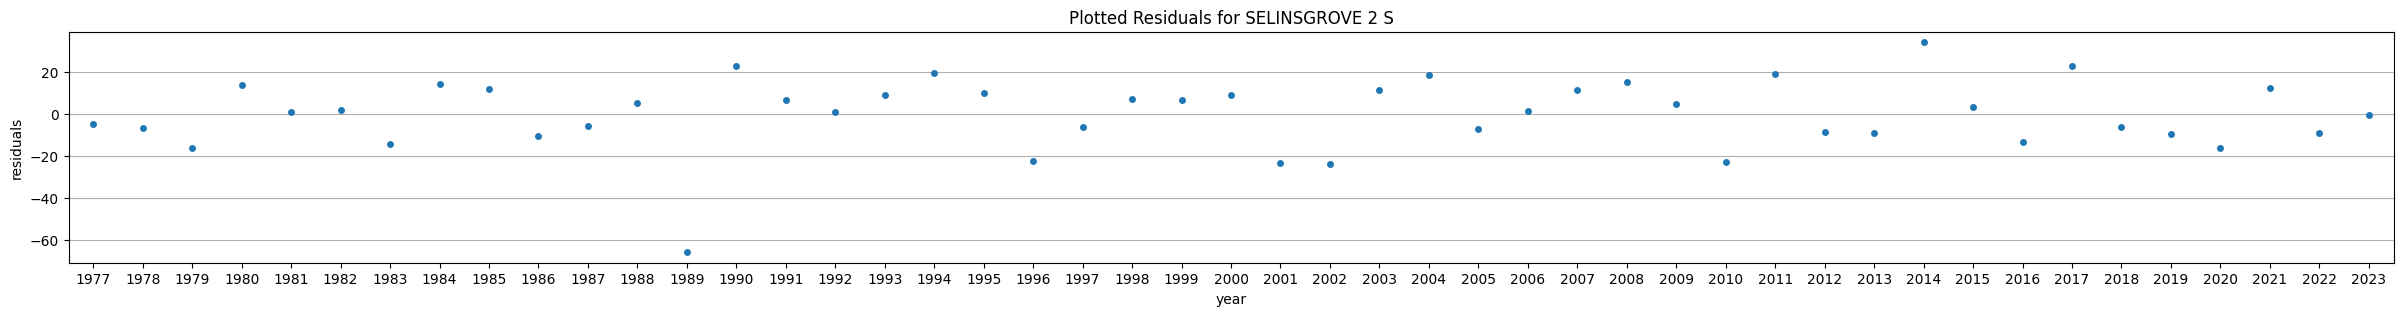

In [34]:
top_stations = ['STATE COLLEGE', 'WARREN', 'TOWANDA 1 S', 'FRANKLIN', 'UNIONTOWN 1 NE', 
                'NEW CASTLE 1 N', 'RIDGWAY', 'SELINSGROVE 2 S']
for station in top_stations:
    station_residuals_plotting(station, 3)

### Heteroscedasticity by Subset

In [35]:
def subset_residuals_plotting(subset, subset_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(subset, X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df_s = residuals_s.to_frame()
    res_df_s = pd.concat([res_df_s, Z_s], axis=1)
    res_df_s.columns = ['residuals', 'year', 'station_name']
    
    res_df_s['bins'] = pd.cut(x= res_df_s['year'], bins = bin_no)
    res_df_s = res_df_s.sort_values(by='bins')
    
    
    fig, axs = plt.subplots(1,bin_no, sharey=True, figsize = (bin_no * 2, 5))
    fig.suptitle(f'Boxplots of Binned Multiple Regression Residuals Data for {subset_name} PA')
    fig.subplots_adjust(wspace = bin_no * 3/5)
    n = 0
    for value in res_df_s['bins'].unique():
        res_df_bin = res_df_s[res_df_s['bins'] == value]
        axs[n].boxplot(res_df_bin['residuals'], notch= True)
        axs[n].set_xlabel(f'{value}, {len(res_df_bin)} pts')
        n = n + 1
    plt.show()

    fig = plt.figure(figsize = (30, 3))
    fig = sns.stripplot(data = res_df_s, x = 'year', y = 'residuals')
    plt.grid(axis='y')
    plt.title(f'Plotted Residuals for {subset_name} PA')
    plt.show()

coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] <139.9]

subsets = {'Coastal': coastal_pa_stations, 'Lakeside': lakeside_pa_stations, 'Inland': inland_pa_stations,
           'Eastern': east_pa_stations, 'Western': west_pa_stations, 'Northern': north_pa_stations, 'Southern': south_pa_stations,
           'Low Elevation': low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

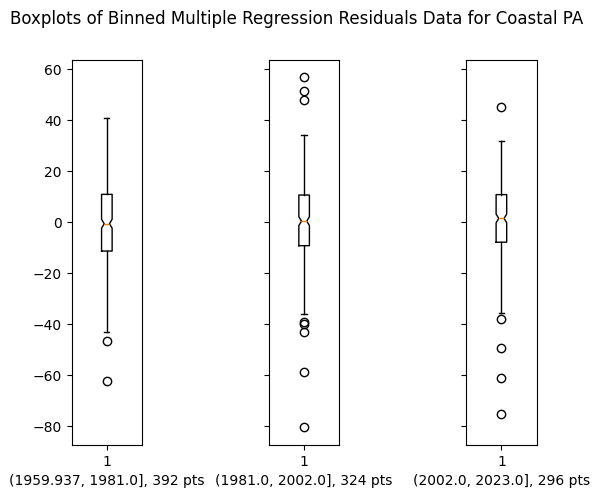

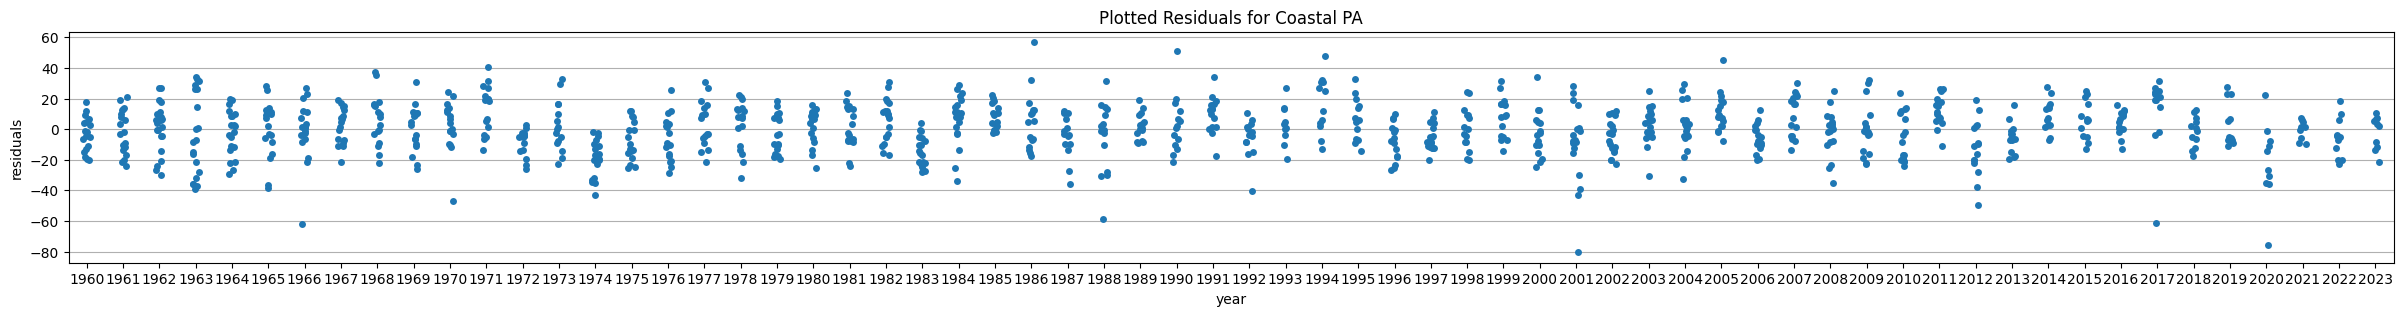

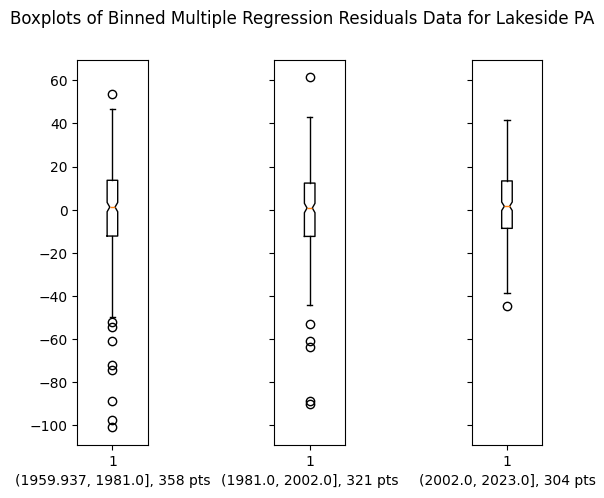

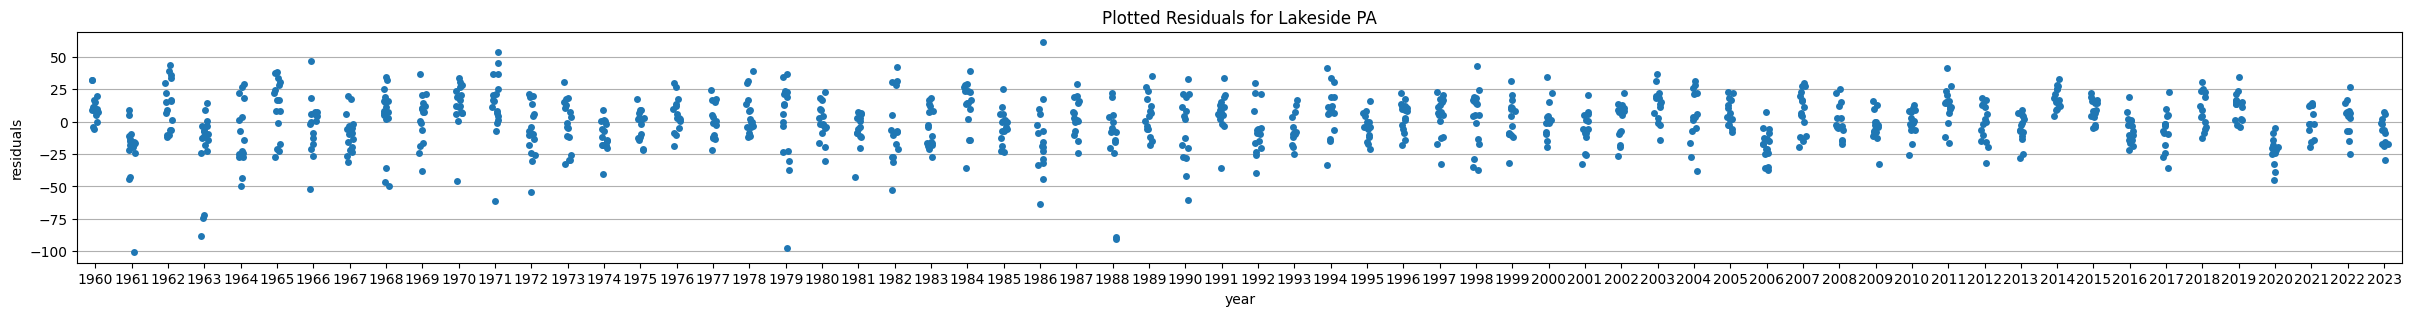

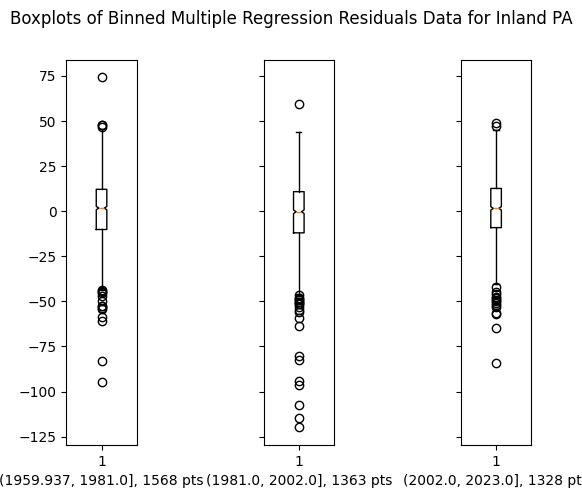

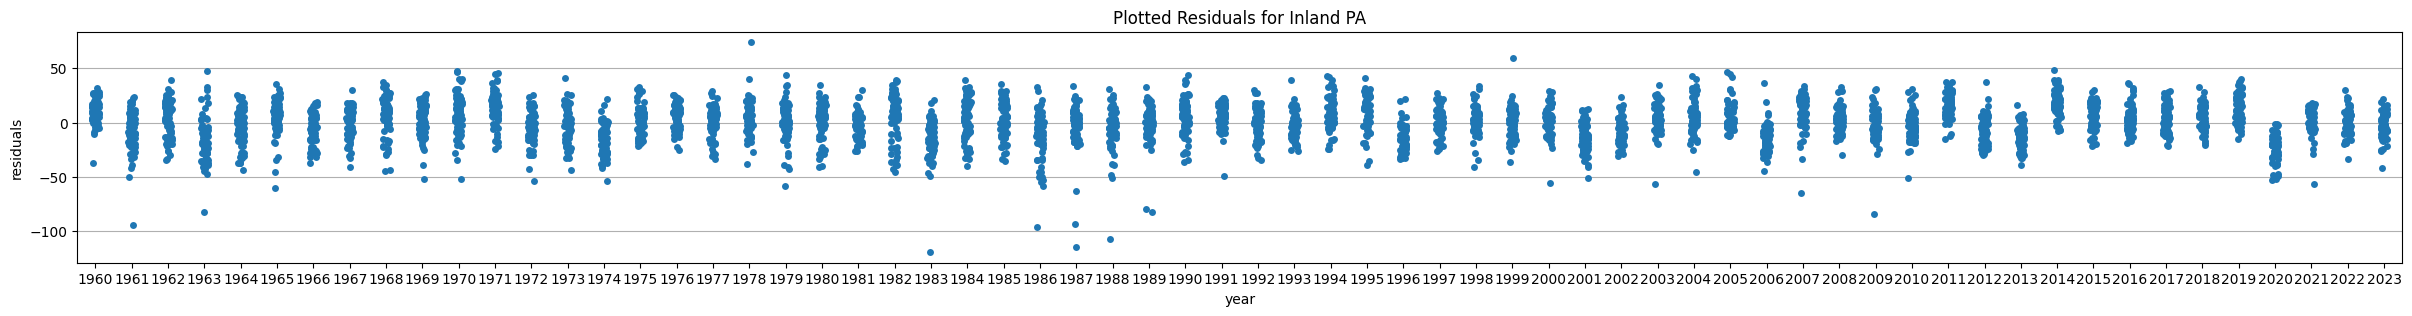

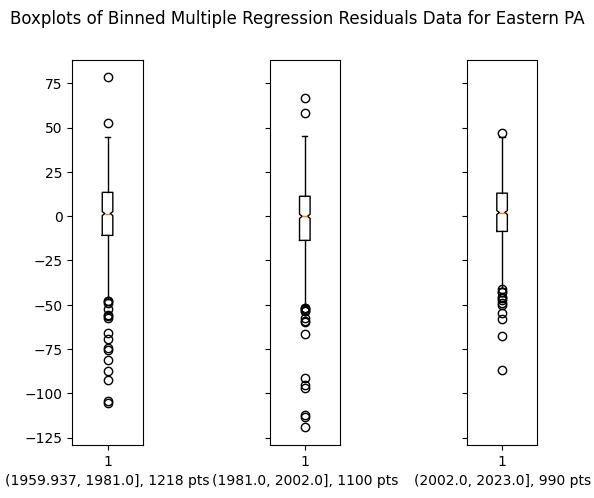

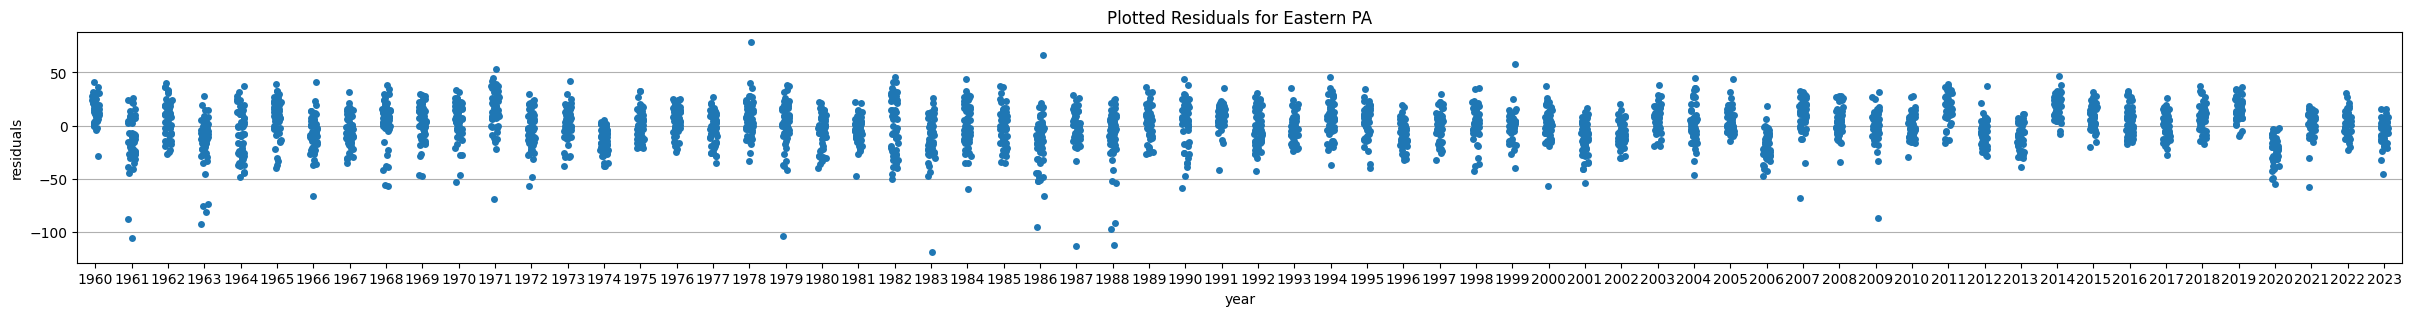

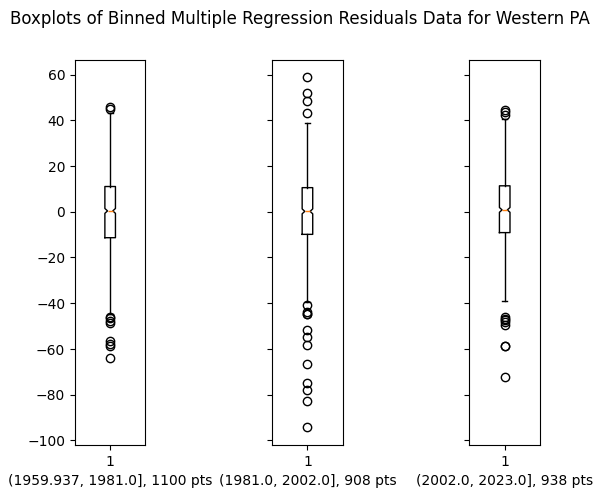

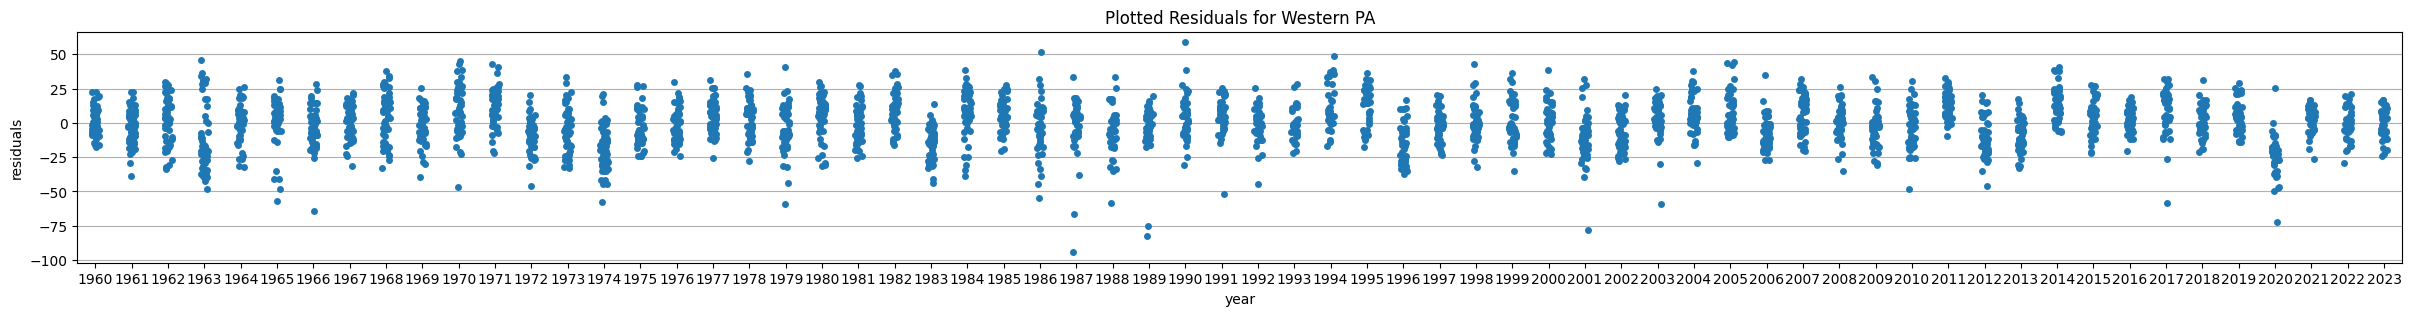

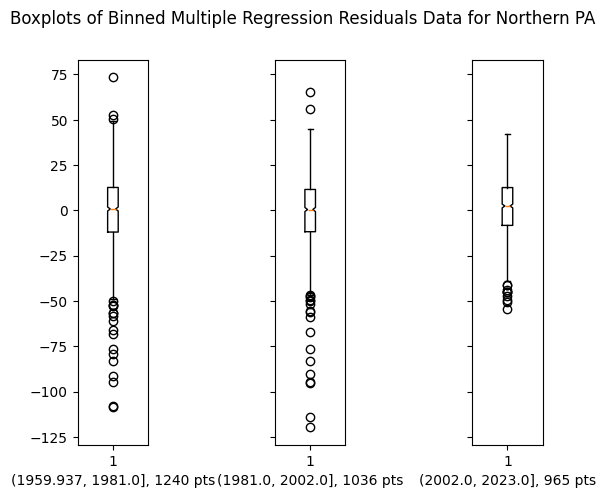

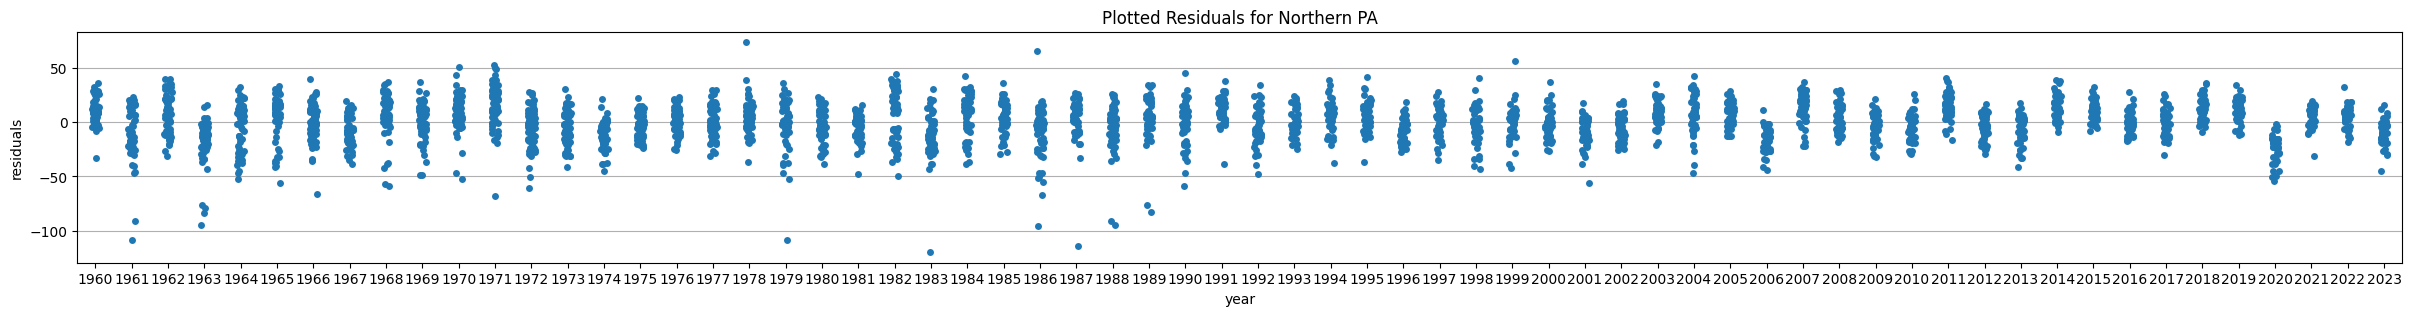

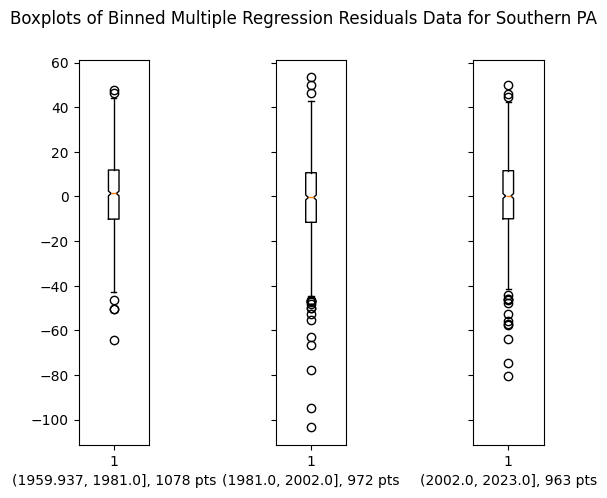

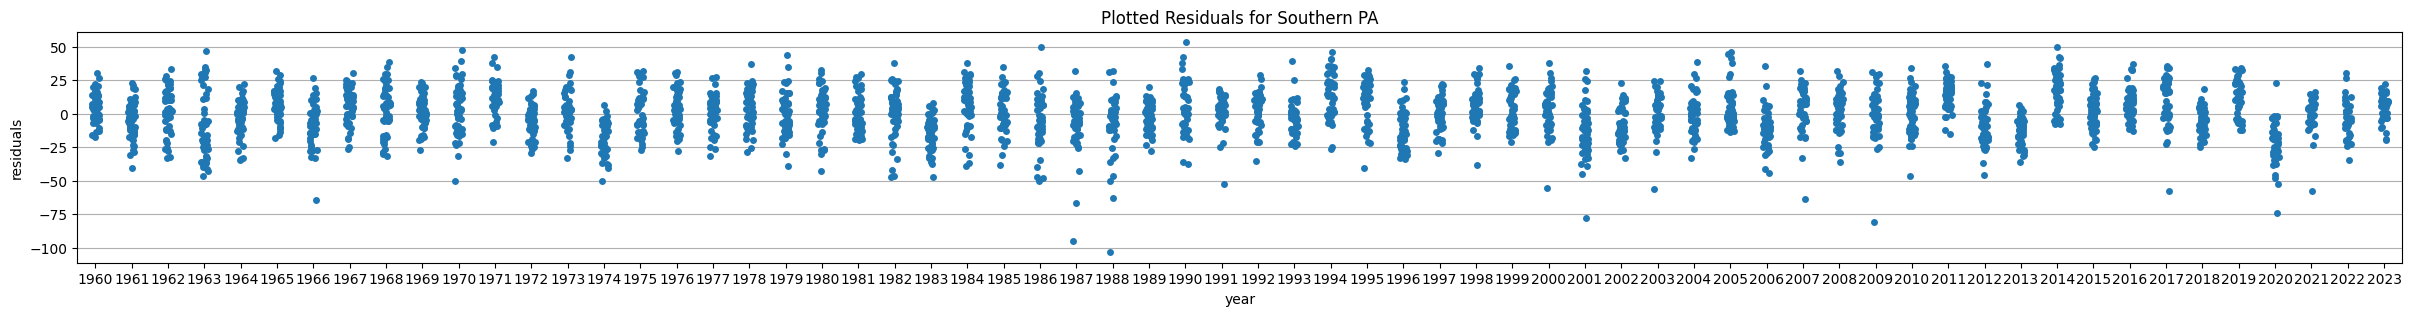

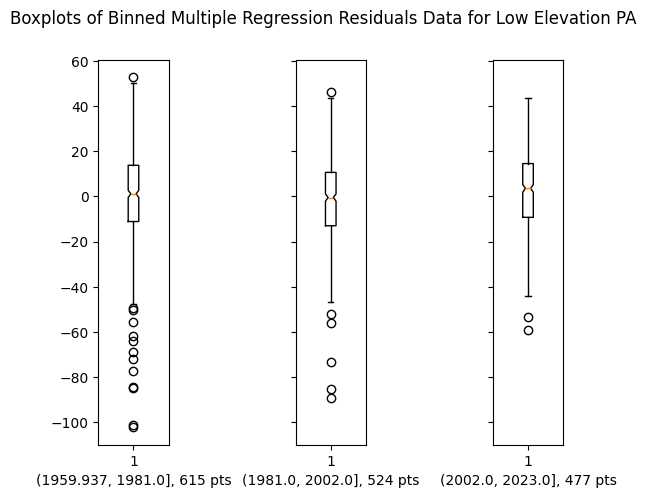

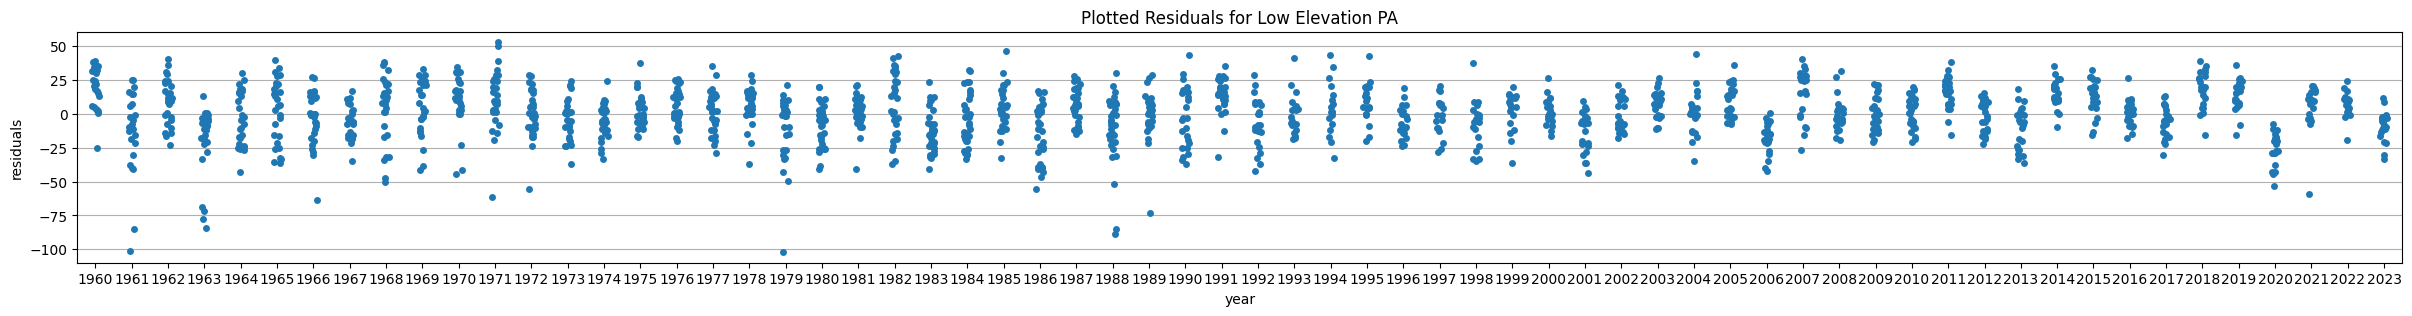

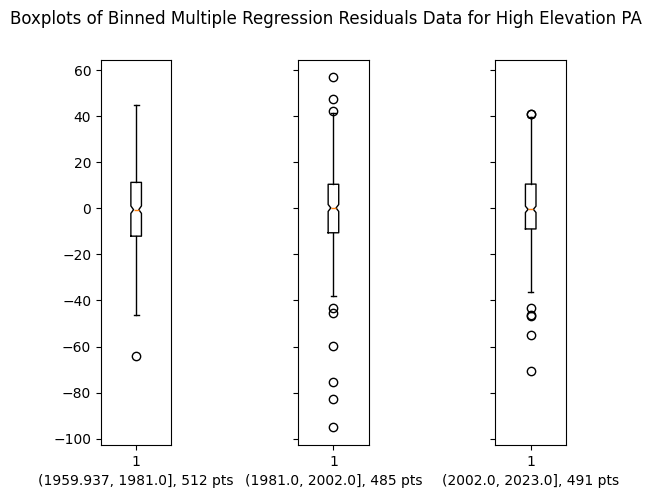

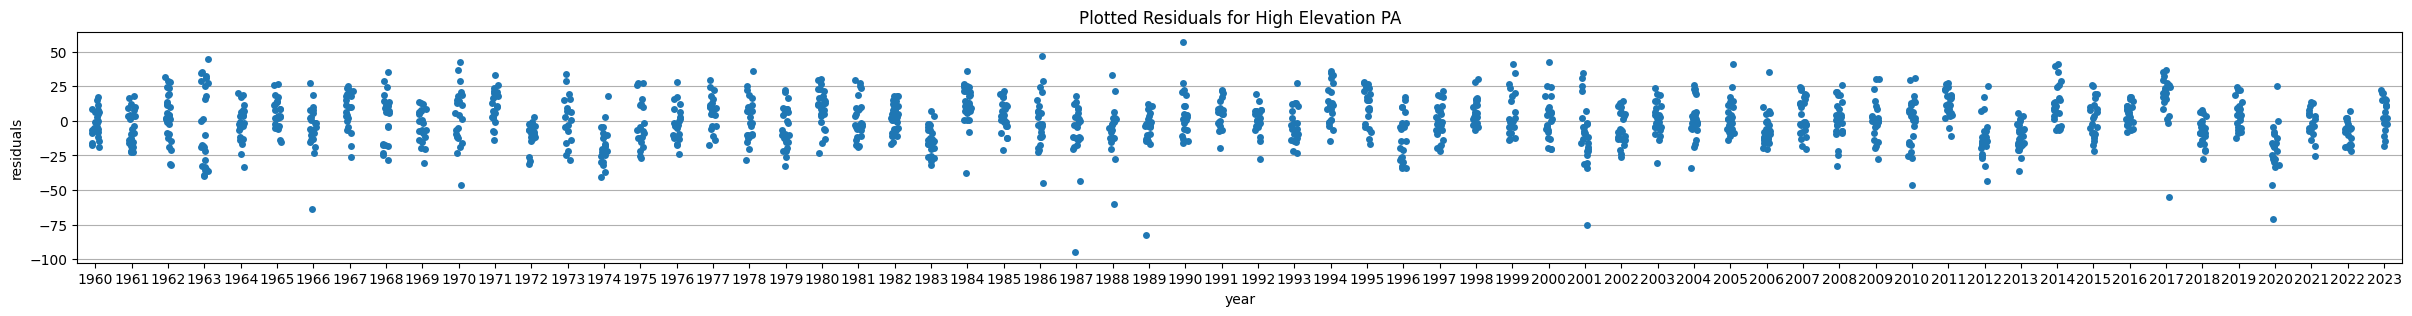

In [36]:
for subset_name, subset in subsets.items():
    subset_residuals_plotting(subset, subset_name, 3)

There are certain graphs of plotted residuals below which appear to show a similar cycle to the strip plot of the entire state's residuals by year. The subsets that most noticeably show this cycle are:
* Western
* Southern
* High Elevation

### Bambi Library Work

In [37]:
import bambi as bmb

In [38]:
covariates = ['dtr_annual', 'oni_annual',
              'nao_djf', 'pwat_station', 'dewpoint_2m_pennsylvania', 'cloud_cover_station']

years = pa_gs['year'].unique().tolist()

covariate_years = {covariate: years for covariate in covariates}

mean_covariates = pd.DataFrame(columns = ['year', 'covariate', 'covariate_yearly_mean'])
var_covariates = pd.DataFrame(columns = ['year', 'covariate', 'covariate_yearly_var'])

for covariate, year in covariate_years.items():
    for y in year:
        pa_gs_y = pa_gs[pa_gs['year'] == y]
        mean_cv = pa_gs_y[covariate].mean()
        var_cv = pa_gs_y[covariate].var()
        mean_covariates.loc[len(mean_covariates)] = [y, covariate, mean_cv]
        var_covariates.loc[len(var_covariates)] = [y, covariate, var_cv]

# Second loop: assign means and variances to new columns (FIXED)
for idx, row in pa_gs.iterrows():
    year_value = row['year']
    
    # Get means for this year
    mean_covariates_yr = mean_covariates[mean_covariates['year'] == year_value]
    for _, cov_row in mean_covariates_yr.iterrows():
        covariate = cov_row['covariate']
        mean_val = cov_row['covariate_yearly_mean']
        pa_gs.loc[idx, f'{covariate}_mean'] = mean_val
    
    # Get variances for this year
    var_covariates_yr = var_covariates[var_covariates['year'] == year_value]
    for _, cov_row in var_covariates_yr.iterrows():
        covariate = cov_row['covariate']
        var_val = cov_row['covariate_yearly_var']
        pa_gs.loc[idx, f'{covariate}_var'] = var_val        

In [39]:
pa_gs.head()

,station_id,year,last_spring_frost_doy,last_spring_frost_date,first_fall_frost_doy,first_fall_frost_date,growing_season_length,dtr_annual,dtr_spring,dtr_summer,...,nao_djf_mean,pwat_station_mean,dewpoint_2m_pennsylvania_mean,cloud_cover_station_mean,dtr_annual_var,oni_annual_var,nao_djf_var,pwat_station_var,dewpoint_2m_pennsylvania_var,cloud_cover_station_var
0,USC00360022,2011,97,2011-04-07,301,2011-10-28,204,10.472299,11.314444,12.800000,...,-0.090,19.051085,5.434528,0.643680,1.072390,1.991874e-31,1.945189e-34,1.060935,3.186998e-30,0.001495
1,USC00360022,2012,88,2012-03-28,287,2012-10-13,199,9.794857,11.177174,9.884783,...,0.795,18.209713,5.463437,0.593113,1.538006,1.945992e-34,0.000000e+00,1.089552,7.970782e-31,0.000303
2,USC00360022,2013,135,2013-05-15,301,2013-10-28,166,10.373088,11.328571,12.740244,...,-0.050,18.049897,4.113082,0.640340,1.109636,7.786555e-34,4.379937e-34,0.959531,7.973433e-31,0.002322
3,USC00360022,2014,115,2014-04-25,307,2014-11-03,192,9.648923,11.374419,10.137838,...,0.815,17.193367,3.305183,0.646727,1.198521,3.114982e-33,0.000000e+00,1.220862,1.794230e-30,0.001075
4,USC00360022,2015,93,2015-04-03,292,2015-10-19,199,9.443731,10.935556,9.436471,...,1.555,18.636061,4.531039,0.642157,1.430161,4.486105e-31,4.984561e-32,1.687313,7.975297e-31,0.000692


In [82]:
def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

var_mean_cols = ['year', 'growing_season_length', 'last_spring_frost_doy', 'first_fall_frost_doy', 'dtr_annual_mean', 'oni_annual_mean',
                 'nao_djf_mean', 'pwat_station_mean', 
                 'dewpoint_2m_pennsylvania_mean', 'cloud_cover_station_mean','dtr_annual_var', 'oni_annual_var', 'nao_djf_var',
                 'pwat_station_var', 'dewpoint_2m_pennsylvania_var', 'cloud_cover_station_var']
var_mean_data = remove_nulls_simple(pa_gs, var_mean_cols)

### Bambi Modeling, Residuals, and Plotting for Growing Season Length

In [85]:
mean_formula_terms = 'dtr_annual_mean + oni_annual_mean + nao_djf_mean + pwat_station_mean + dewpoint_2m_pennsylvania_mean + cloud_cover_station_mean'
var_formula_terms = 'dtr_annual_var + oni_annual_var + nao_djf_var + pwat_station_var + dewpoint_2m_pennsylvania_var + cloud_cover_station_var'
formula = bmb.Formula(f"growing_season_length ~ {mean_formula_terms} + year",
                      f"sigma ~ {var_formula_terms} + year")
model = bmb.Model(formula, data=var_mean_data)
output = model.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.343       15          367.46 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.354       7           221.48 draws/s       0:00:09    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.525       15          234.63 draws/s       0:00:08    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.479       7           344.68 draws/s       0:00:05    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


Sampling: [Intercept, cloud_cover_station_mean, dewpoint_2m_pennsylvania_mean, dtr_annual_mean, nao_djf_mean, oni_annual_mean, pwat_station_mean, sigma_Intercept, sigma_cloud_cover_station_var, sigma_dewpoint_2m_pennsylvania_var, sigma_dtr_annual_var, sigma_nao_djf_var, sigma_oni_annual_var, sigma_pwat_station_var, sigma_year, year]


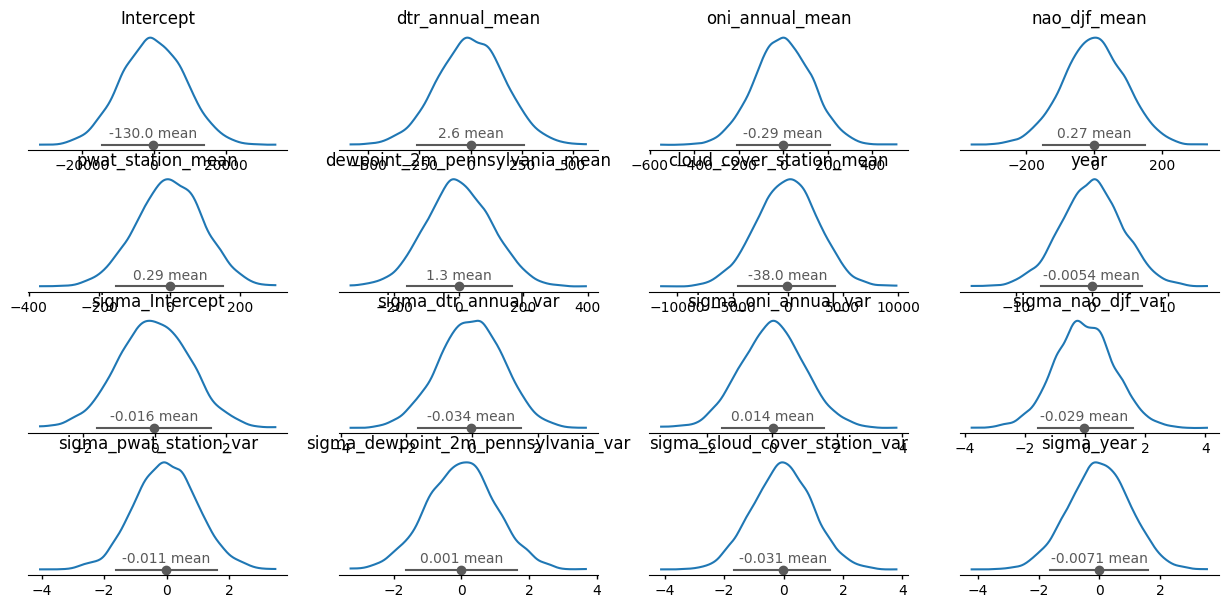

In [42]:
model.plot_priors()

In [43]:
import arviz as az

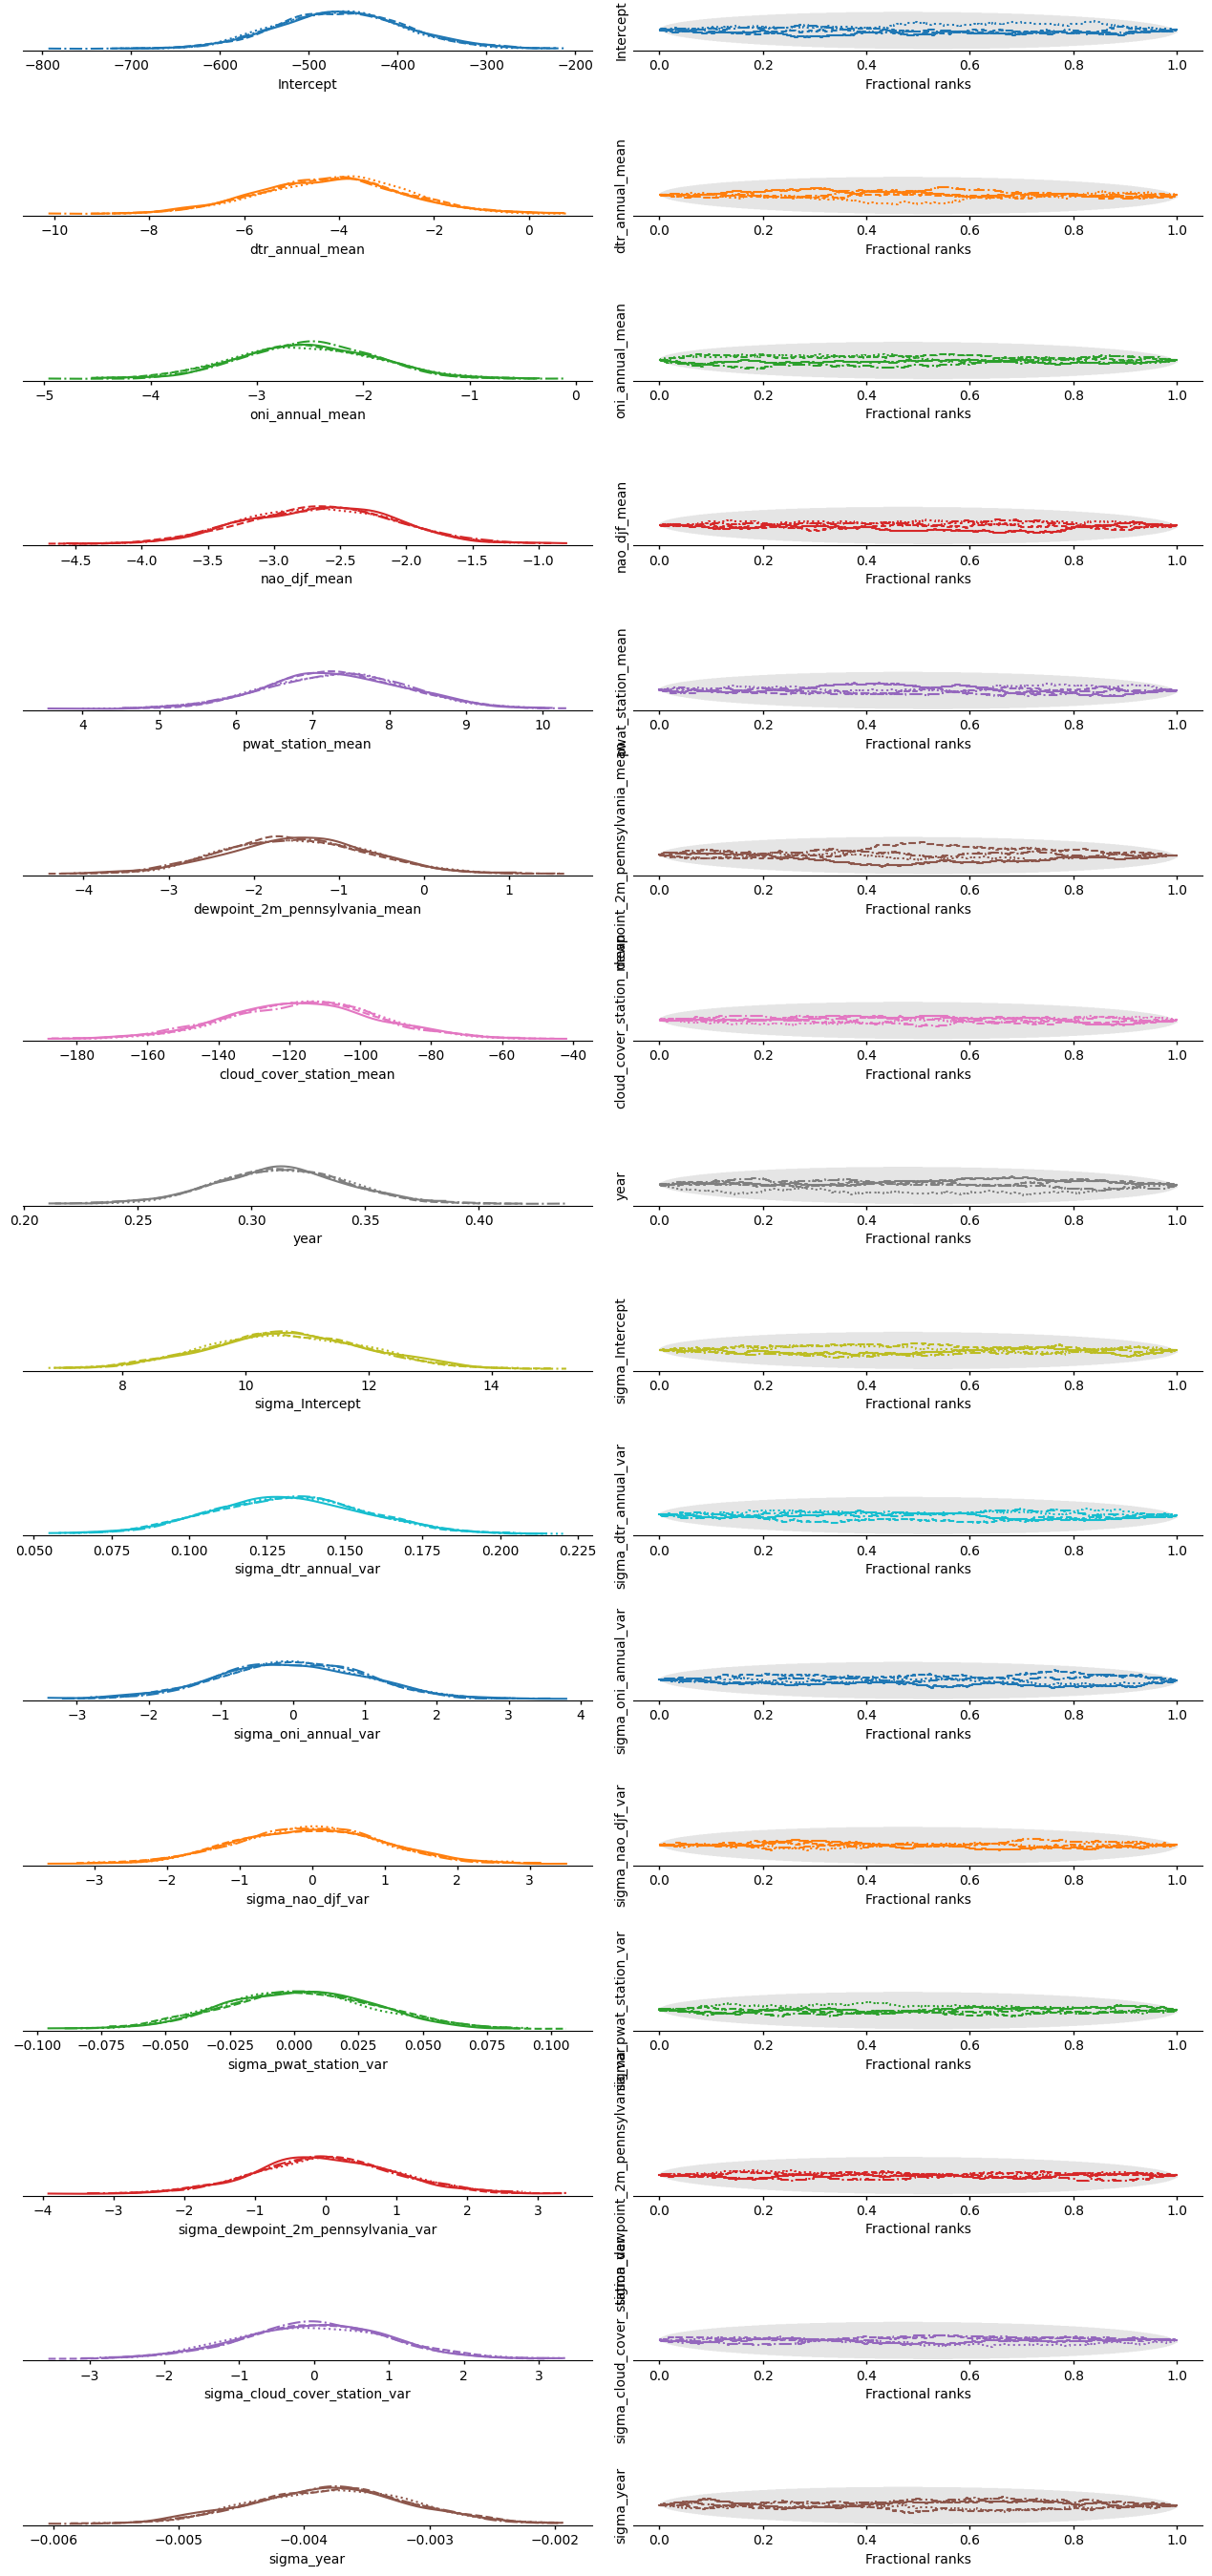

In [44]:
plot_collection = az.plot_rank_dist(output)
plt.tight_layout()
plt.subplots_adjust(hspace=3)
plt.show()

In [45]:
az.summary(output)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-464,72,-580,-350,3013,2874,1.00,1.3,0.97
dtr_annual_mean,-4.15,1.5,-6.6,-1.8,2894,2682,1.00,0.028,0.02
oni_annual_mean,-2.52,0.64,-3.5,-1.5,3713,3046,1.00,0.01,0.0074
nao_djf_mean,-2.66,0.57,-3.6,-1.8,3422,3280,1.00,0.0097,0.0069
pwat_station_mean,7.32,0.91,5.9,8.8,2918,2871,1.00,0.017,0.012
dewpoint_2m_pennsylvania_mean,-1.49,0.85,-2.8,-0.13,2881,3262,1.00,0.016,0.011
cloud_cover_station_mean,-115.9,21.1,-150,-81,2920,2560,1.00,0.39,0.28
year,0.3135,0.0284,0.27,0.36,4119,3087,1.00,0.00044,0.00032
sigma_Intercept,10.66,1.27,8.6,13,3474,3155,1.00,0.022,0.015
sigma_dtr_annual_var,0.1323,0.0249,0.093,0.17,3648,3196,1.00,0.00041,0.00029


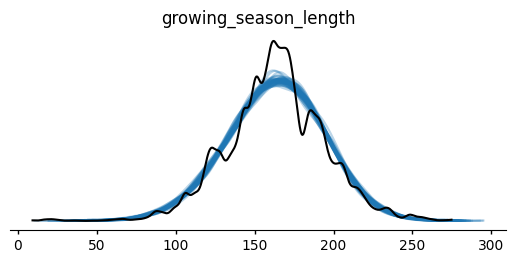

In [46]:
model.predict(output, kind="response")
az.plot_ppc_dist(output)
plt.show()

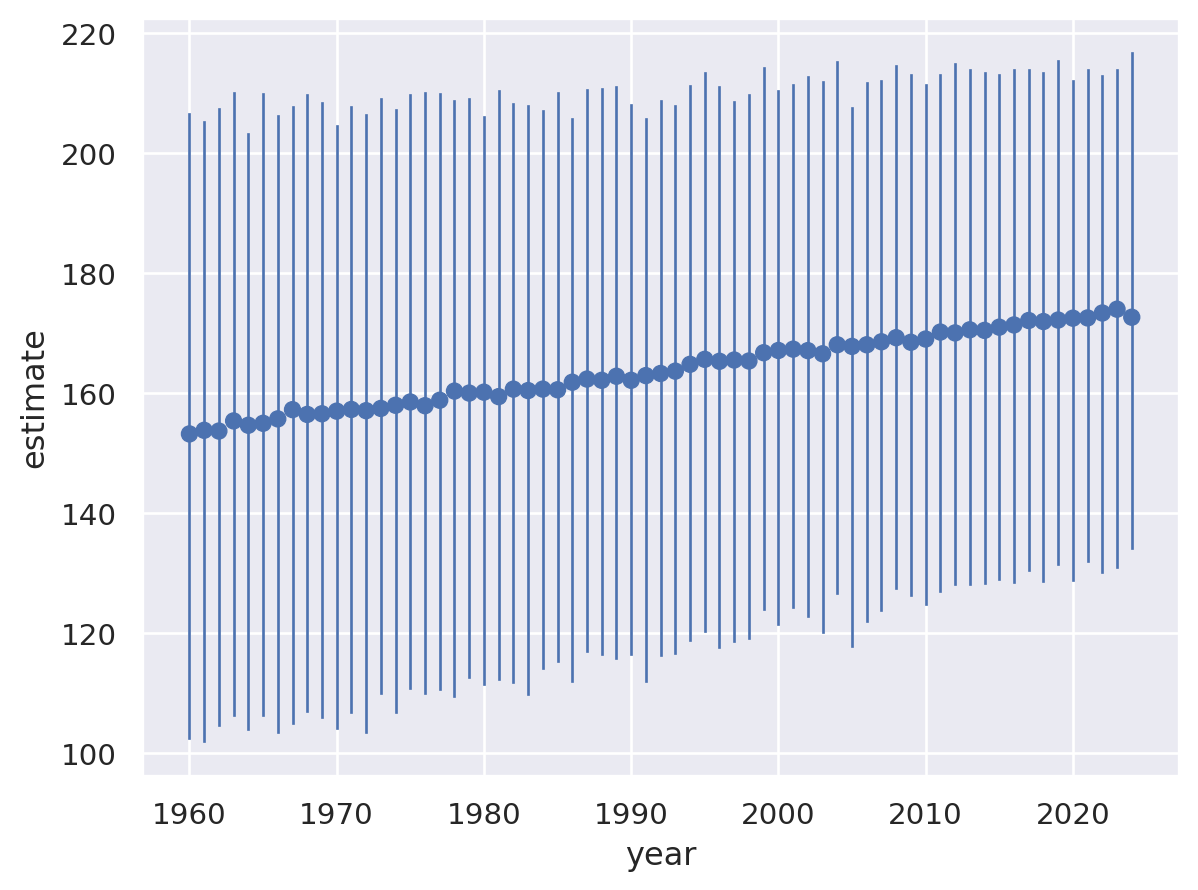

In [106]:
bmb.interpret.plot_predictions(model, output, "year", target="growing_season_length")

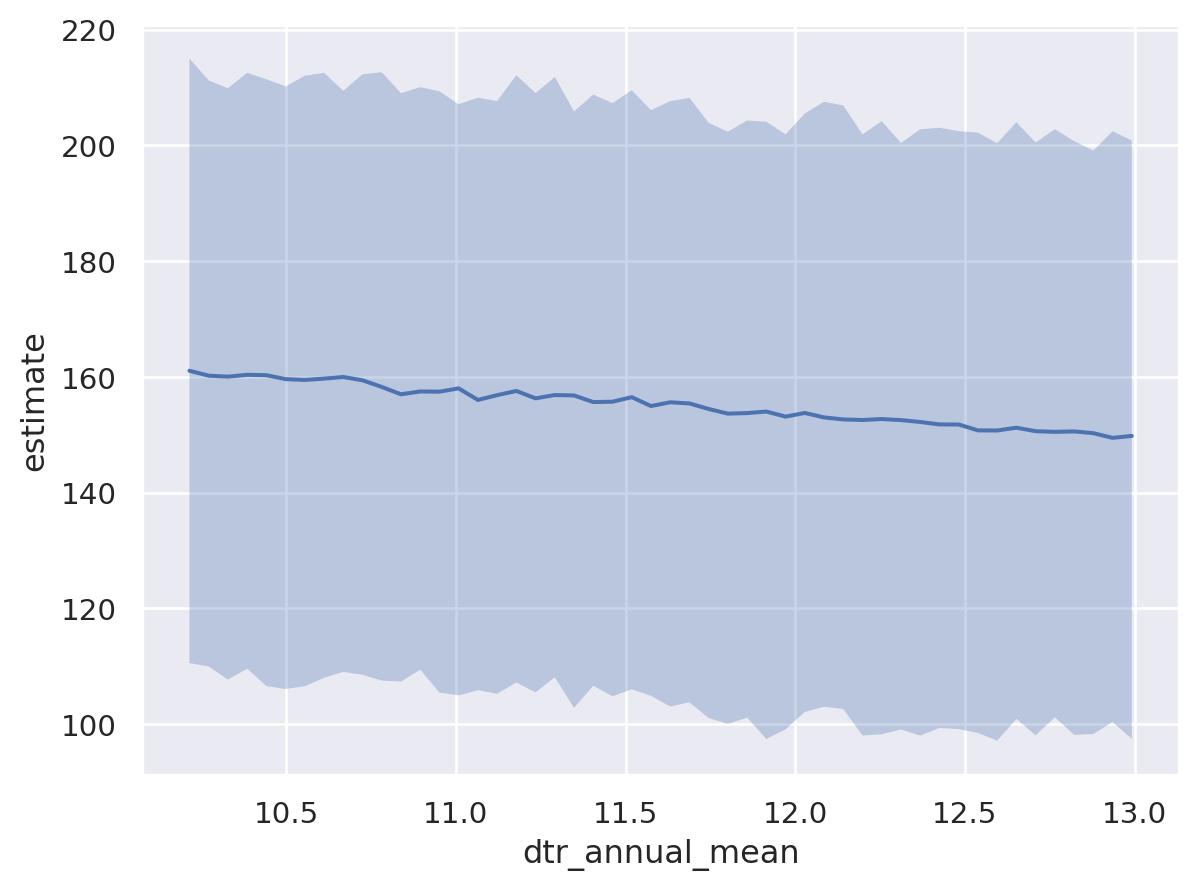

In [48]:
bmb.interpret.plot_predictions(model, output, "dtr_annual_mean", target="growing_season_length")

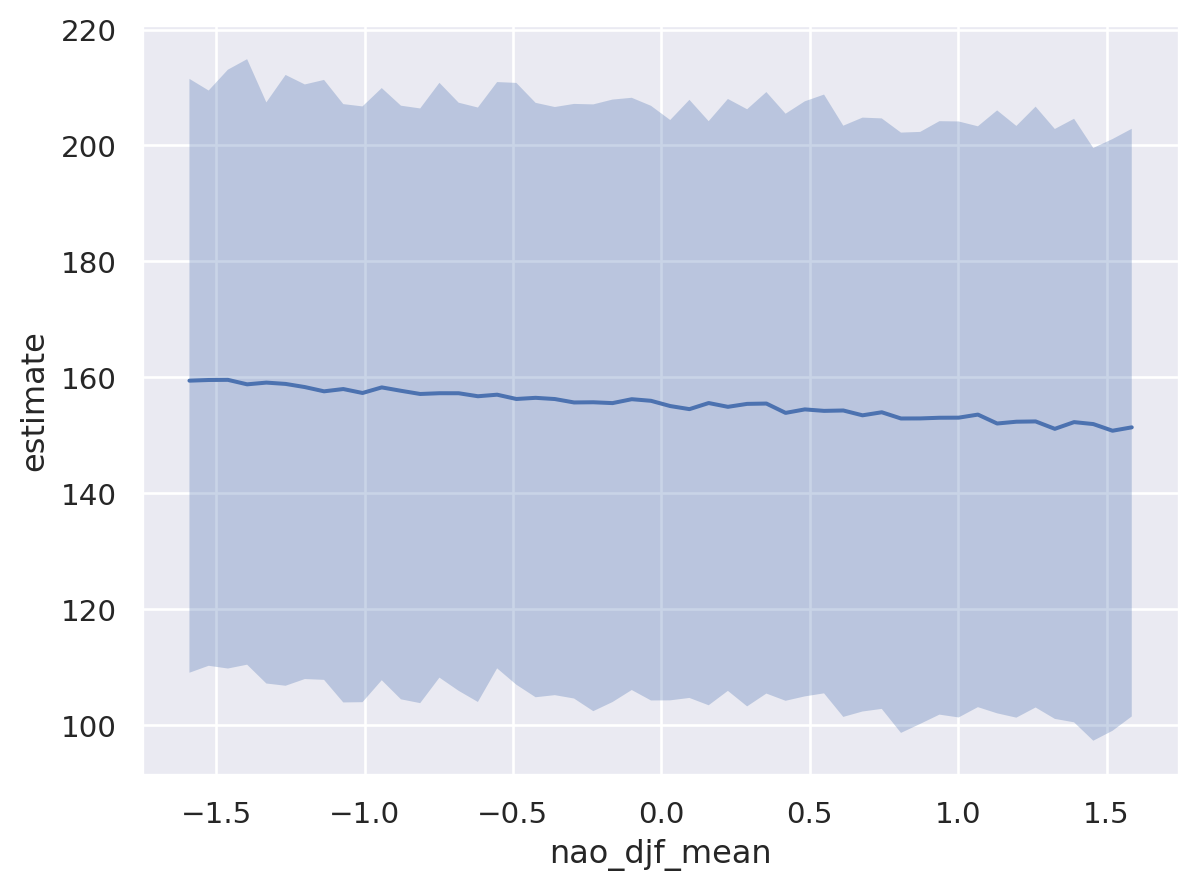

In [49]:
bmb.interpret.plot_predictions(model, output, "nao_djf_mean", target="growing_season_length")

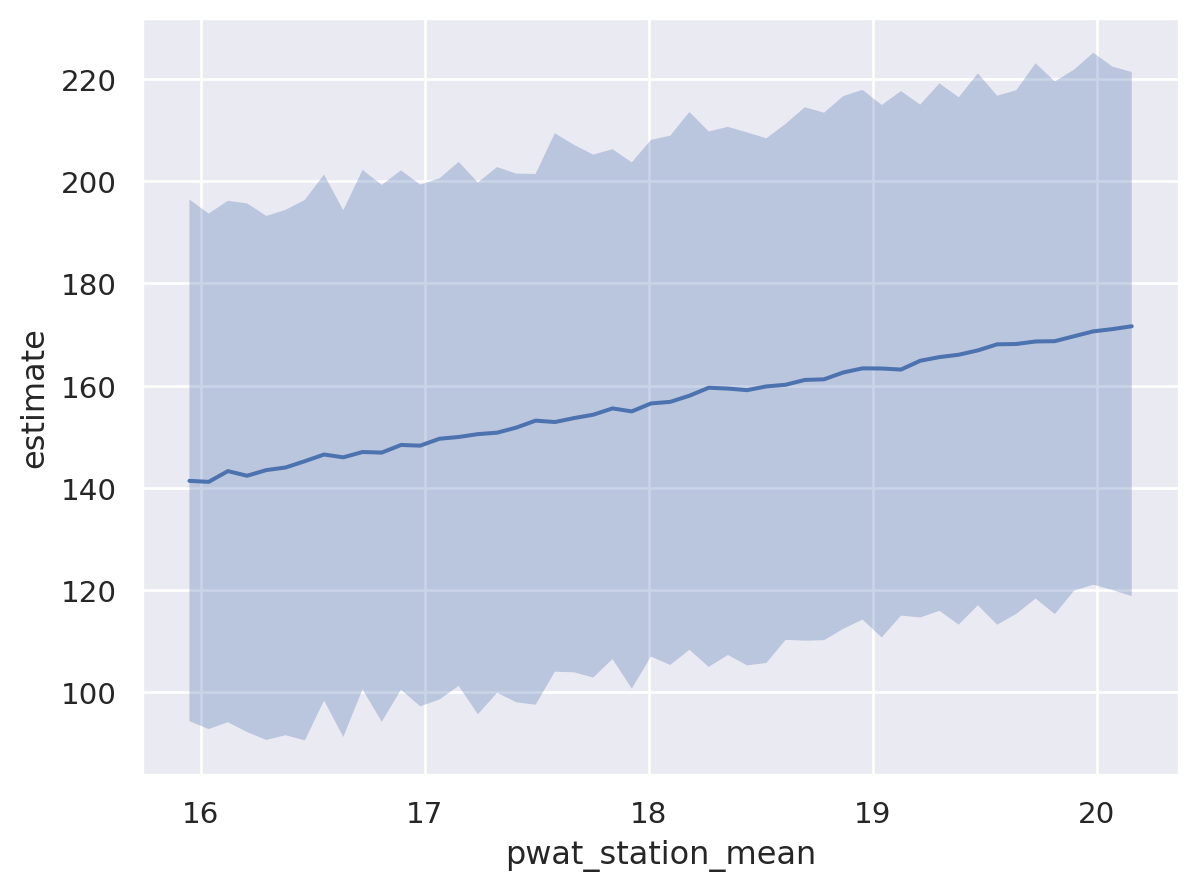

In [50]:
bmb.interpret.plot_predictions(model, output, "pwat_station_mean", target="growing_season_length")

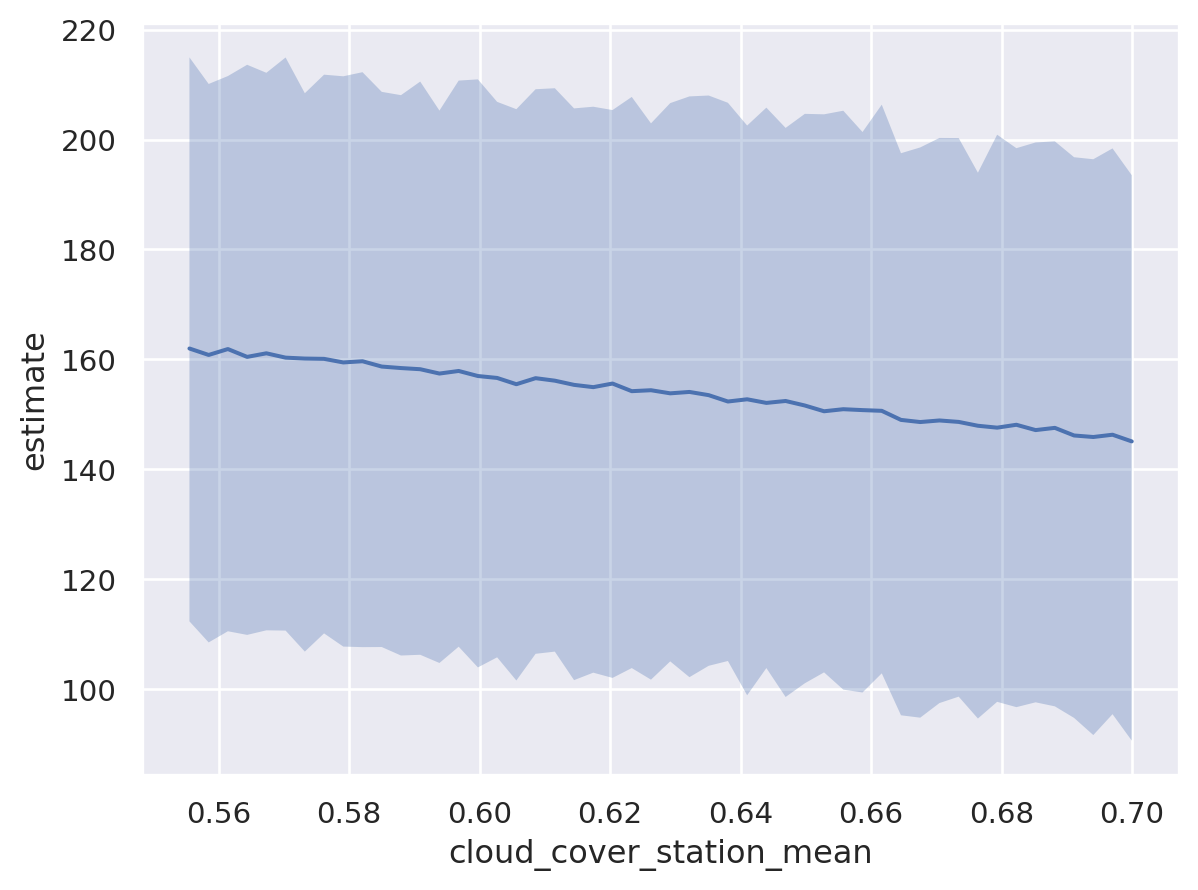

In [51]:
bmb.interpret.plot_predictions(model, output, "cloud_cover_station_mean", target="growing_season_length")

In [77]:
resid = pa_gs['growing_season_length'] - model.predict(output, inplace=False).posterior["mu"].mean().values

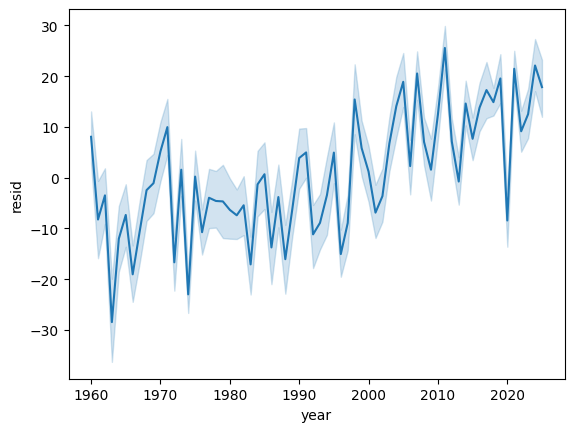

In [80]:
pa_gs_resid = pd.concat([pa_gs[['year', 'growing_season_length']], resid], axis=1)
pa_gs_resid.columns = ['year', 'growing_season_length', 'resid']
sns.lineplot(data= pa_gs_resid, x= 'year', y='resid')
plt.show()

In [54]:
postsigma_year = output.posterior["sigma_year"]
q05, q95 = float(postsigma_year.quantile(.05)), float(postsigma_year.quantile(.95))

print(q05)
print(q95)

-0.004804461089073738
-0.0027487012664163756


In [65]:
model_2 = bmb.Model("growing_season_length ~ year + (1|station_id)", data = pa_gs)
output_2 = model_2.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.182       15          1198.35 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.163       15          1082.10 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.186       15          1160.18 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.175       15          1296.14 draws/s      0:00:01    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [68]:
az.summary(output_2)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,18.238,0.165,18,19,3421,2417,1.00,0.0028,0.0019
Intercept,-592,29.7,-640,-540,2111,2355,1.00,0.65,0.47
year,0.3798,0.0149,0.36,0.4,2164,2327,1.00,0.00032,0.00023
1|station_id_sigma,24.8,1.4,23,27,81,281,1.06,0.15,0.11
1|station_id[USC00360022],10.2,5.1,2,18,333,1685,1.02,0.28,0.2
...,...,...,...,...,...,...,...,...,...
1|station_id[USW00014860],19.3,2.9,15,24,46,110,1.06,0.42,0.3
1|station_id[USW00014861],39.1,4.5,32,46,147,1230,1.02,0.37,0.26
1|station_id[USW00093778],-1.9,3.8,-8.2,4.1,88,632,1.04,0.41,0.28
1|station_id[USW00094732],37.9,2.9,33,43,48,131,1.06,0.41,0.29


### Bambi Modeling for Last Spring Frost

In [88]:
mean_formula_terms = 'dtr_annual_mean + oni_annual_mean + nao_djf_mean + pwat_station_mean + dewpoint_2m_pennsylvania_mean + cloud_cover_station_mean'
var_formula_terms = 'dtr_annual_var + oni_annual_var + nao_djf_var + pwat_station_var + dewpoint_2m_pennsylvania_var + cloud_cover_station_var'
formula_lsf = bmb.Formula(f"last_spring_frost_doy ~ {mean_formula_terms} + year",
                      f"sigma ~ {var_formula_terms} + year")
model_lsf = bmb.Model(formula_lsf, data=var_mean_data)
output_lsf = model_lsf.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.396       7           231.06 draws/s       0:00:08    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.570       15          272.56 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.543       7           319.38 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.476       7           391.13 draws/s       0:00:05    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


Sampling: [Intercept, cloud_cover_station_mean, dewpoint_2m_pennsylvania_mean, dtr_annual_mean, nao_djf_mean, oni_annual_mean, pwat_station_mean, sigma_Intercept, sigma_cloud_cover_station_var, sigma_dewpoint_2m_pennsylvania_var, sigma_dtr_annual_var, sigma_nao_djf_var, sigma_oni_annual_var, sigma_pwat_station_var, sigma_year, year]


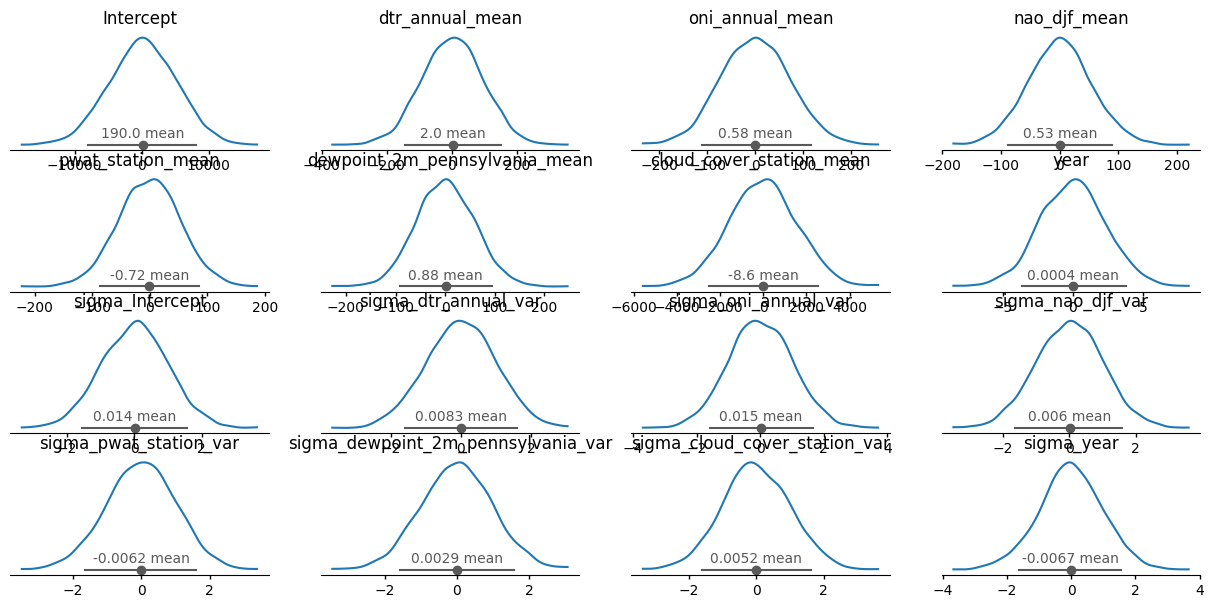

In [89]:
model_lsf.plot_priors()

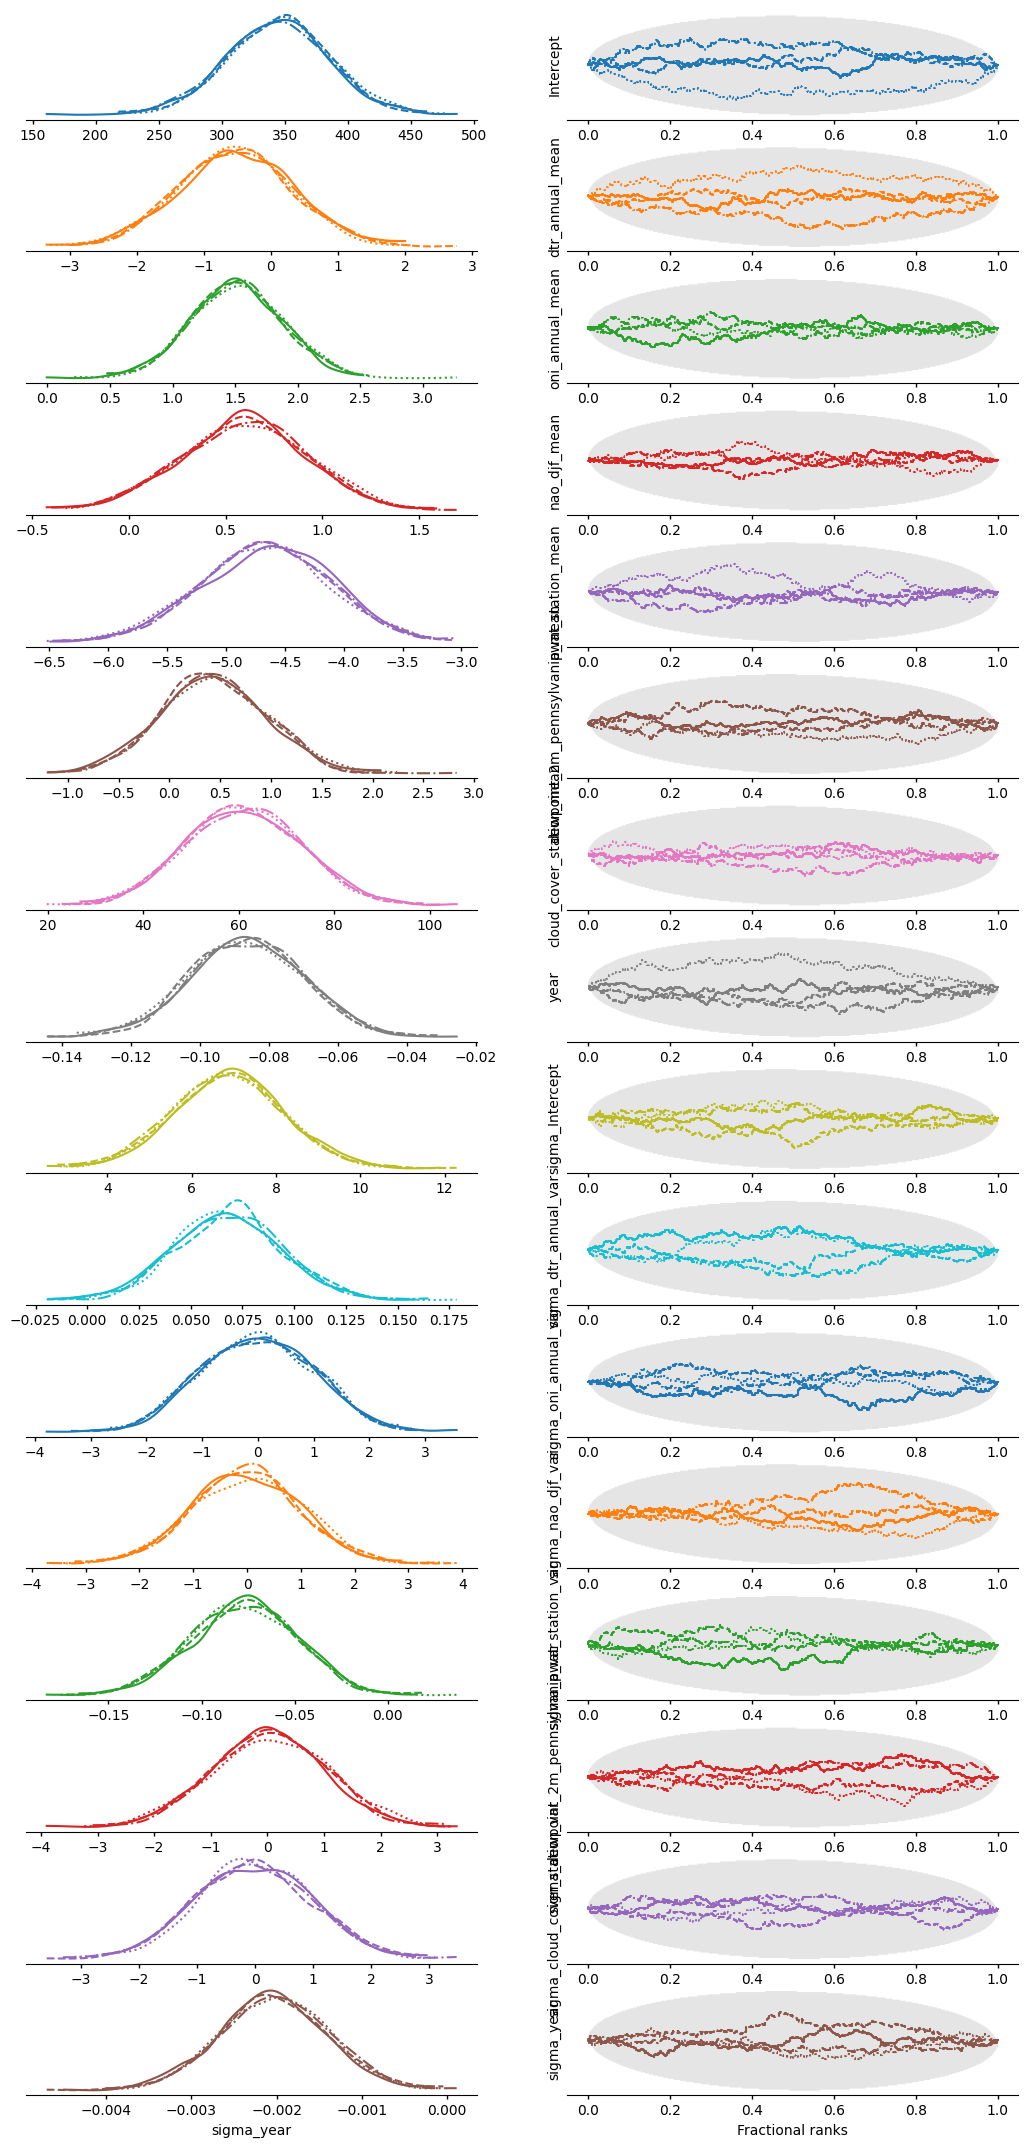

In [90]:
az.plot_rank_dist(output_lsf)
plt.show()

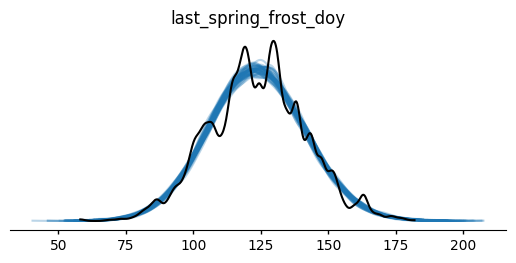

In [91]:
model_lsf.predict(output_lsf, kind="response")
az.plot_ppc_dist(output_lsf)
plt.show()

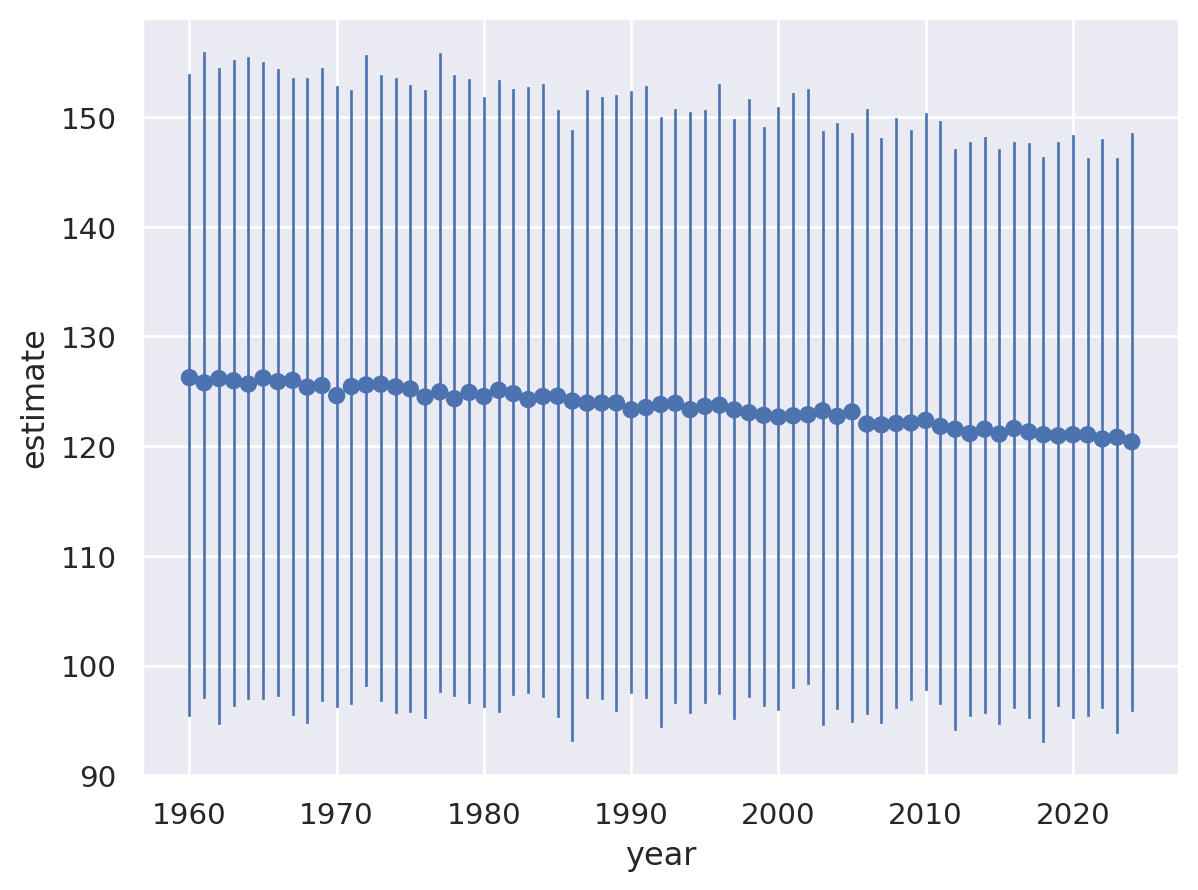

In [92]:
bmb.interpret.plot_predictions(model_lsf, output_lsf, "year", target="last_spring_frost_doy")

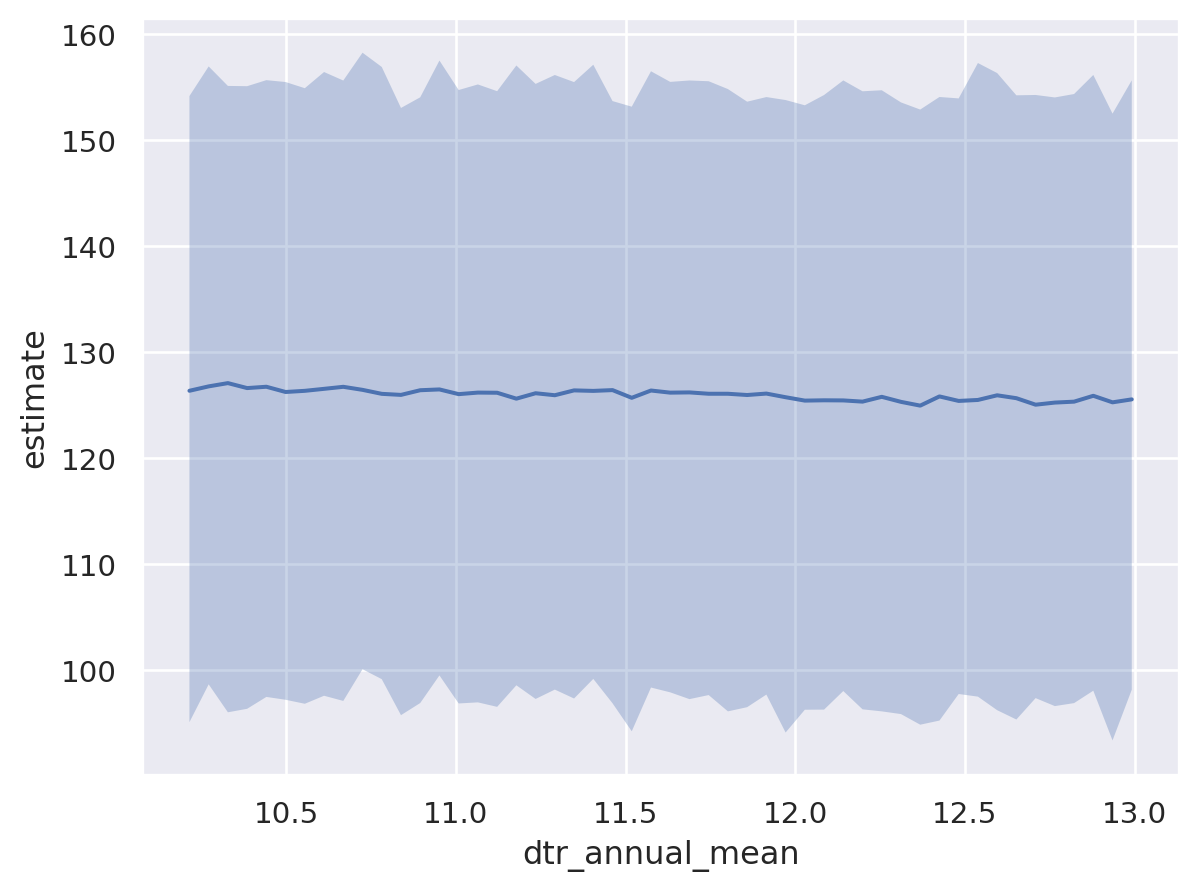

In [93]:
bmb.interpret.plot_predictions(model_lsf, output_lsf, "dtr_annual_mean", target="last_spring_frost_doy")

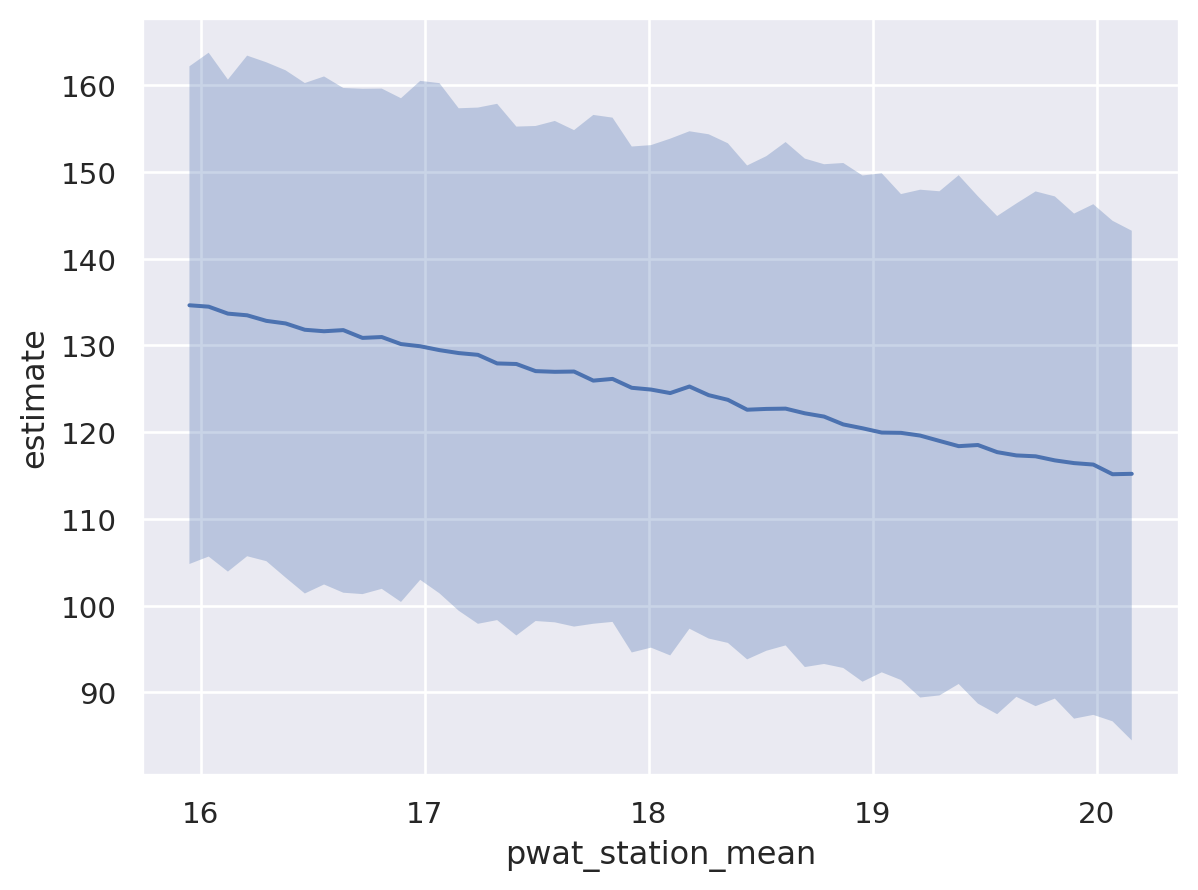

In [107]:
bmb.interpret.plot_predictions(model_lsf, output_lsf, "pwat_station_mean", target="last_spring_frost_doy")

In [100]:
postsigma_year_lsf = output_lsf.posterior["sigma_year"]
q05_lsf, q95_lsf = float(postsigma_year_lsf.quantile(.05)), float(postsigma_year_lsf.quantile(.95))

print(q05_lsf)
print(q95_lsf)

-0.003085753602948329
-0.0009692120245704425


### First Fall Frost Bambi Modeling

In [94]:
mean_formula_terms = 'dtr_annual_mean + oni_annual_mean + nao_djf_mean + pwat_station_mean + dewpoint_2m_pennsylvania_mean + cloud_cover_station_mean'
var_formula_terms = 'dtr_annual_var + oni_annual_var + nao_djf_var + pwat_station_var + dewpoint_2m_pennsylvania_var + cloud_cover_station_var'
formula_fff = bmb.Formula(f"first_fall_frost_doy ~ {mean_formula_terms} + year",
                      f"sigma ~ {var_formula_terms} + year")
model_fff = bmb.Model(formula_fff, data=var_mean_data)
output_fff = model_fff.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.456       7           368.34 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.393       15          416.52 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.488       7           411.09 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.556       7           227.73 draws/s       0:00:08    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


Sampling: [Intercept, cloud_cover_station_mean, dewpoint_2m_pennsylvania_mean, dtr_annual_mean, nao_djf_mean, oni_annual_mean, pwat_station_mean, sigma_Intercept, sigma_cloud_cover_station_var, sigma_dewpoint_2m_pennsylvania_var, sigma_dtr_annual_var, sigma_nao_djf_var, sigma_oni_annual_var, sigma_pwat_station_var, sigma_year, year]


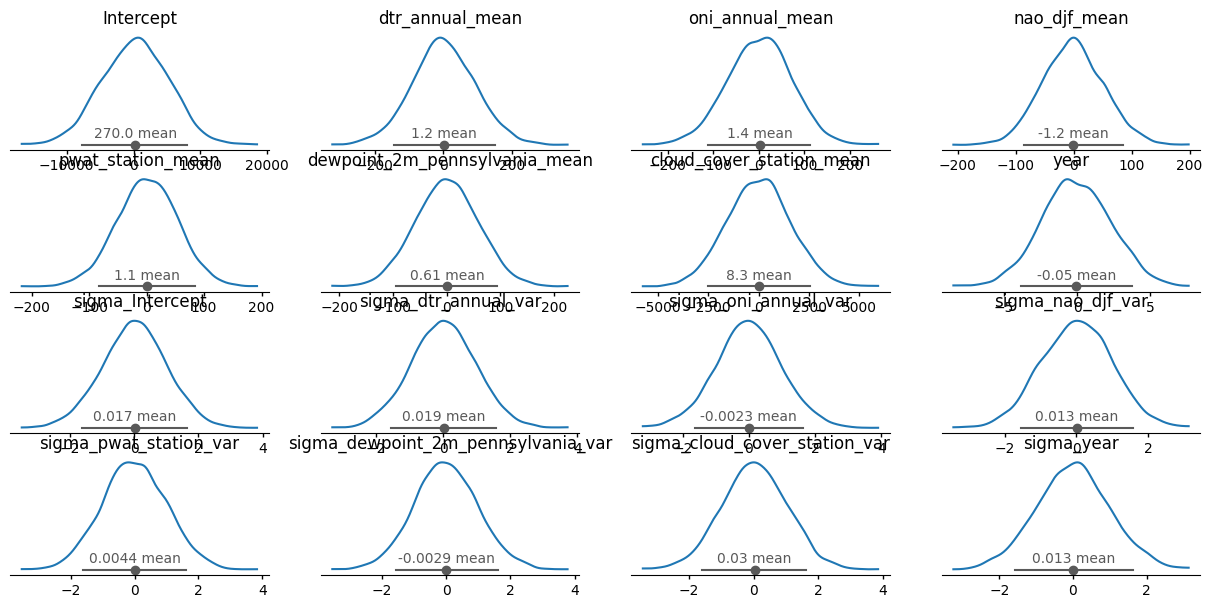

In [95]:
model_fff.plot_priors()

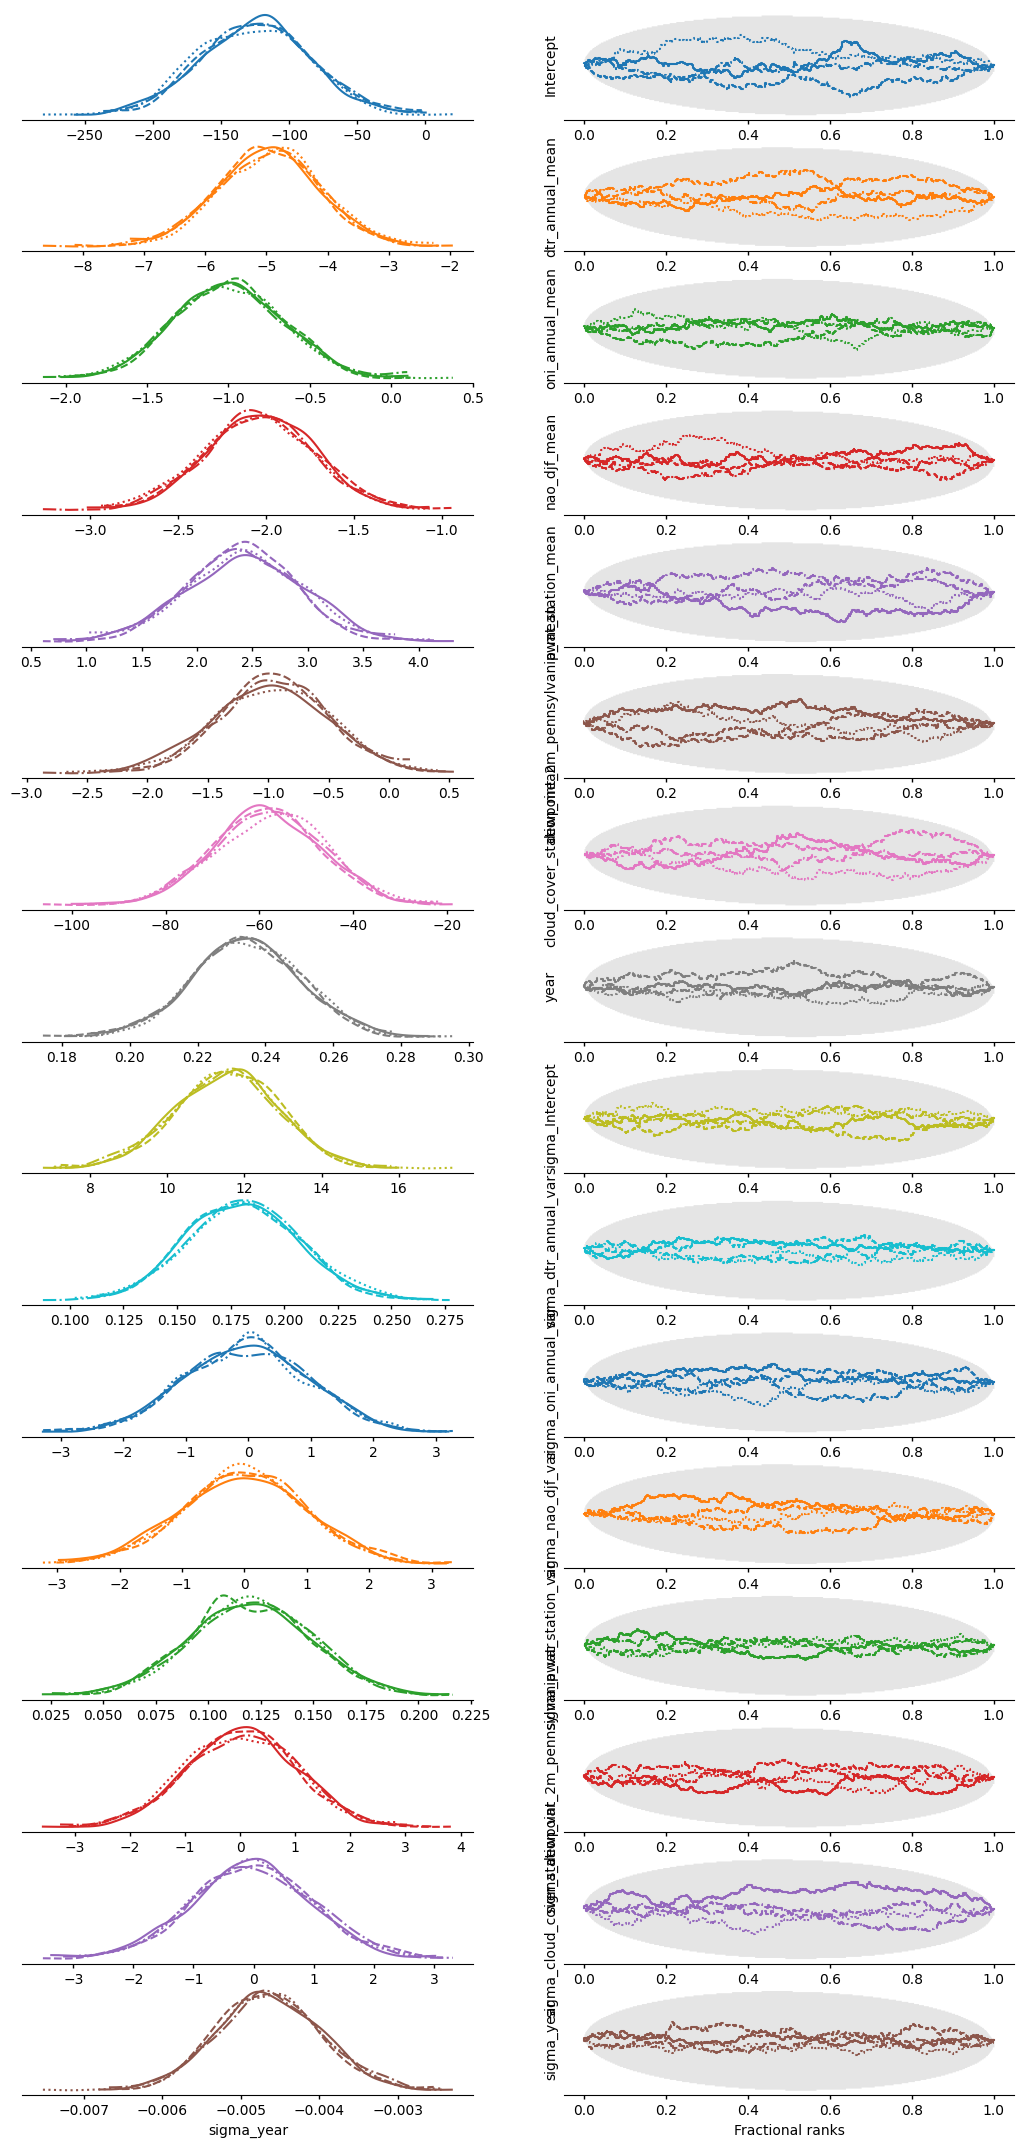

In [96]:
az.plot_rank_dist(output_fff)
plt.show()

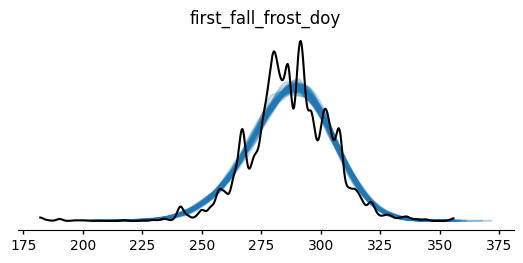

In [97]:
model_fff.predict(output_fff, kind="response")
az.plot_ppc_dist(output_fff)
plt.show()

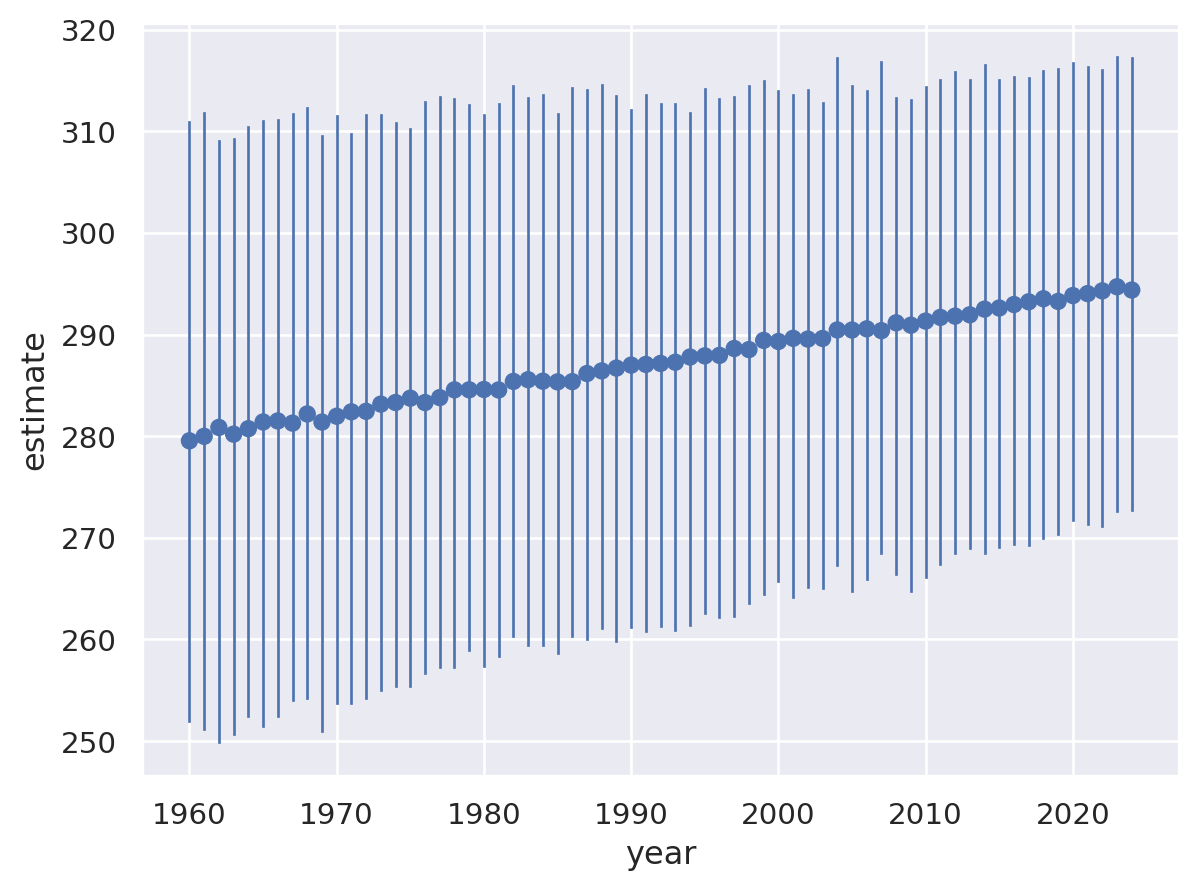

In [98]:
bmb.interpret.plot_predictions(model_fff, output_fff, "year", target="first_fall_frost_doy")

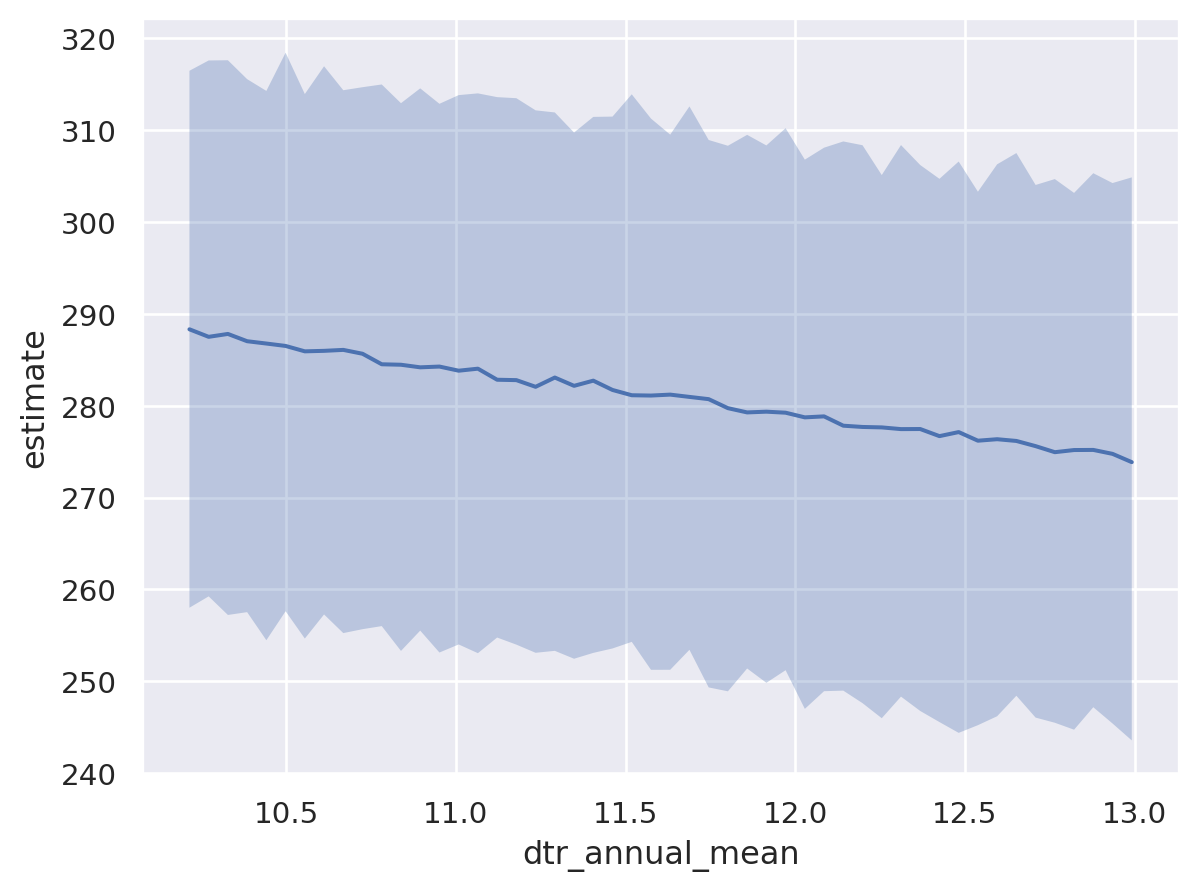

In [99]:
bmb.interpret.plot_predictions(model_fff, output_fff, "dtr_annual_mean", target="first_fall_frost_doy")

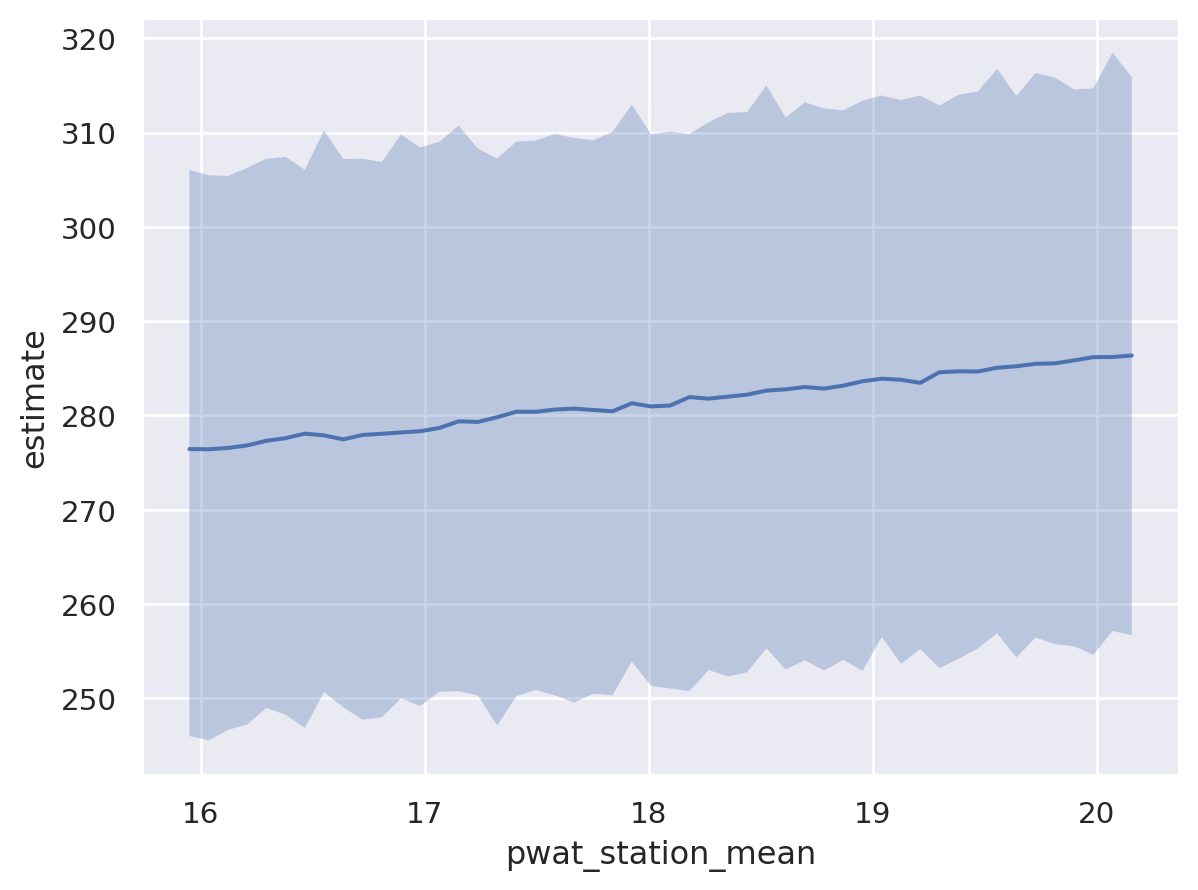

In [108]:
bmb.interpret.plot_predictions(model_fff, output_fff, "pwat_station_mean", target="first_fall_frost_doy")

In [101]:
postsigma_year_fff = output_fff.posterior["sigma_year"]
q05_fff, q95_fff = float(postsigma_year_fff.quantile(.05)), float(postsigma_year_fff.quantile(.95))

print(q05_fff)
print(q95_fff)

-0.0056826597256163635
-0.003539262270912325


### Misc Modeling

In [114]:
covariates_str = 'dtr_annual + oni_annual + nao_djf + pwat_station + dewpoint_2m_pennsylvania + cloud_cover_station'
formula_3 = bmb.Formula(f"growing_season_length ~ {covariates_str} + year")  
model_3 = bmb.Model(formula_3, data= pa_gs, dropna = True)
output_3 = model_3.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.711       7           1267.51 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.480       7           1163.56 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.554       7           1292.37 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.638       15          1173.87 draws/s      0:00:01    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


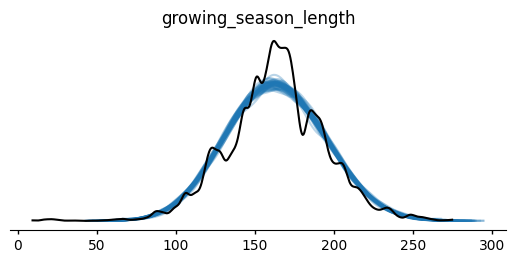

In [115]:
model_3.predict(output_3, kind="response")
az.plot_ppc_dist(output_3)
plt.show()

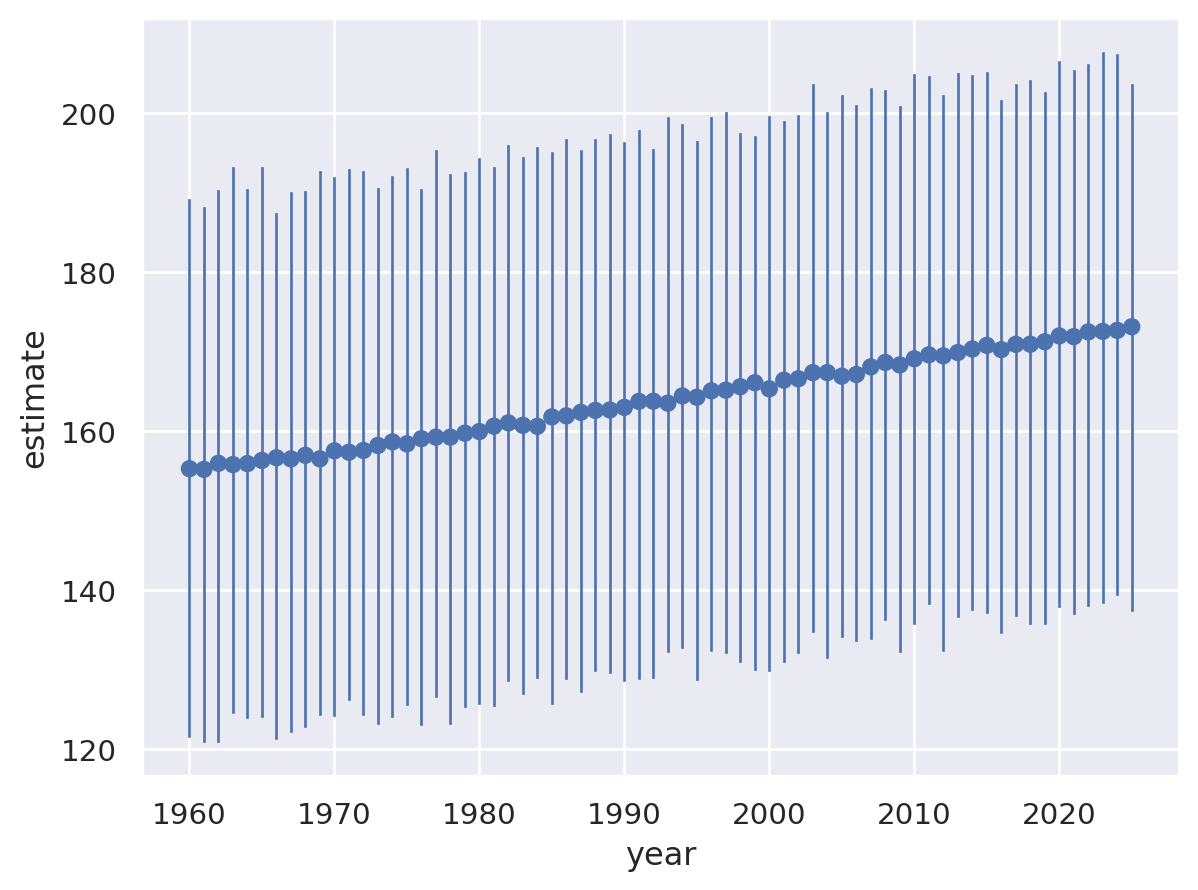

In [116]:
bmb.interpret.plot_predictions(model_3, output_3, "year", target="growing_season_length")